In [68]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import tensorflow as tf
import xgboost as xgb
import os
import warnings
from tensorflow.keras.layers import Dense, LSTM, Conv1D, MaxPooling1D, TimeDistributed, Flatten, Dropout, RepeatVector
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss, ccf
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from math import sqrt

%matplotlib inline

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [69]:
warnings.simplefilter(action='ignore', category=(FutureWarning, UserWarning))

In [70]:
# Read the datasets

df_weather = pd.read_csv(
    './energy-dataset/weather_features.csv', 
    parse_dates=['dt_iso']
)

df_energy = pd.read_csv(
    './energy-dataset/energy_dataset.csv', 
    parse_dates=['time']
)

In [71]:
df_energy.head()

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


In [72]:
# Drop unusable columns

df_energy = df_energy.drop(['generation fossil coal-derived gas','generation fossil oil shale', 
                            'generation fossil peat', 'generation geothermal', 
                            'generation hydro pumped storage aggregated', 'generation marine', 
                            'generation wind offshore', 'forecast wind offshore eday ahead',
                            'total load forecast', 'forecast solar day ahead',
                            'forecast wind onshore day ahead'], 
                            axis=1)

In [73]:
df_energy.describe().round(2)

,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind onshore,total load actual,price day ahead,price actual
count,35045.00,35046.00,35046.00,35046.00,35045.00,35045.00,35045.00,35046.00,35047.00,35046.00,35046.00,35046.00,35045.00,35046.00,35028.00,35064.00,35064.00
mean,383.51,448.06,5622.74,4256.07,298.32,475.58,972.12,2605.11,6263.91,60.23,85.64,1432.67,269.45,5464.48,28696.94,49.87,57.88
std,85.35,354.57,2201.83,1961.60,52.52,792.41,400.78,1835.20,839.67,20.24,14.08,1680.12,50.20,3213.69,4574.99,14.62,14.20
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,18041.00,2.06,9.33
25%,333.00,0.00,4126.00,2527.00,263.00,0.00,637.00,1077.25,5760.00,53.00,73.00,71.00,240.00,2933.00,24807.75,41.49,49.35
50%,367.00,509.00,4969.00,4474.00,300.00,68.00,906.00,2164.00,6566.00,57.00,88.00,616.00,279.00,4849.00,28901.00,50.52,58.02
75%,433.00,757.00,6429.00,5838.75,330.00,616.00,1250.00,3757.00,7025.00,80.00,97.00,2578.00,310.00,7398.00,32192.00,60.53,68.01
max,592.00,999.00,20034.00,8359.00,449.00,4523.00,2000.00,9728.00,7117.00,106.00,119.00,5792.00,357.00,17436.00,41015.00,101.99,116.80


In [74]:
df_energy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   time                                         35064 non-null  object 
 1   generation biomass                           35045 non-null  float64
 2   generation fossil brown coal/lignite         35046 non-null  float64
 3   generation fossil gas                        35046 non-null  float64
 4   generation fossil hard coal                  35046 non-null  float64
 5   generation fossil oil                        35045 non-null  float64
 6   generation hydro pumped storage consumption  35045 non-null  float64
 7   generation hydro run-of-river and poundage   35045 non-null  float64
 8   generation hydro water reservoir             35046 non-null  float64
 9   generation nuclear                           35047 non-null  float64
 10

In [75]:
# Convert time to datetime object and set it as index

df_energy['time'] = pd.to_datetime(df_energy['time'], utc=True, infer_datetime_format=True)
df_energy = df_energy.set_index('time')

In [76]:
# Find NaNs and duplicates in df_energy

print('There are {} missing values or NaNs in df_energy.'
      .format(df_energy.isnull().values.sum()))

temp_energy = df_energy.duplicated(keep='first').sum()

print('There are {} duplicate rows in df_energy based on all columns.'
      .format(temp_energy))

There are 292 missing values or NaNs in df_energy.
There are 0 duplicate rows in df_energy based on all columns.


In [77]:
# Find the number of NaNs in each column

df_energy.isnull().sum(axis=0)

generation biomass                             19
generation fossil brown coal/lignite           18
generation fossil gas                          18
generation fossil hard coal                    18
generation fossil oil                          19
generation hydro pumped storage consumption    19
generation hydro run-of-river and poundage     19
generation hydro water reservoir               18
generation nuclear                             17
generation other                               18
generation other renewable                     18
generation solar                               18
generation waste                               19
generation wind onshore                        18
total load actual                              36
price day ahead                                 0
price actual                                    0
dtype: int64

In [78]:
# Define a function to plot different types of time-series

def plot_series(df=None, column=None, series=pd.Series([]), 
                label=None, ylabel=None, title=None, start=0, end=None):
    """
    Plots a certain time-series which has either been loaded in a dataframe
    and which constitutes one of its columns or it a custom pandas series 
    created by the user. The user can define either the 'df' and the 'column' 
    or the 'series' and additionally, can also define the 'label', the 
    'ylabel', the 'title', the 'start' and the 'end' of the plot.
    """
    sns.set()
    fig, ax = plt.subplots(figsize=(30, 12))
    ax.set_xlabel('Time', fontsize=16)
    if column:
        ax.plot(df[column][start:end], label=label)
        ax.set_ylabel(ylabel, fontsize=16)
    if series.any():
        ax.plot(series, label=label)
        ax.set_ylabel(ylabel, fontsize=16)
    if label:
        ax.legend(fontsize=16)
    if title:
        ax.set_title(title, fontsize=24)
    ax.grid(True)
    return ax

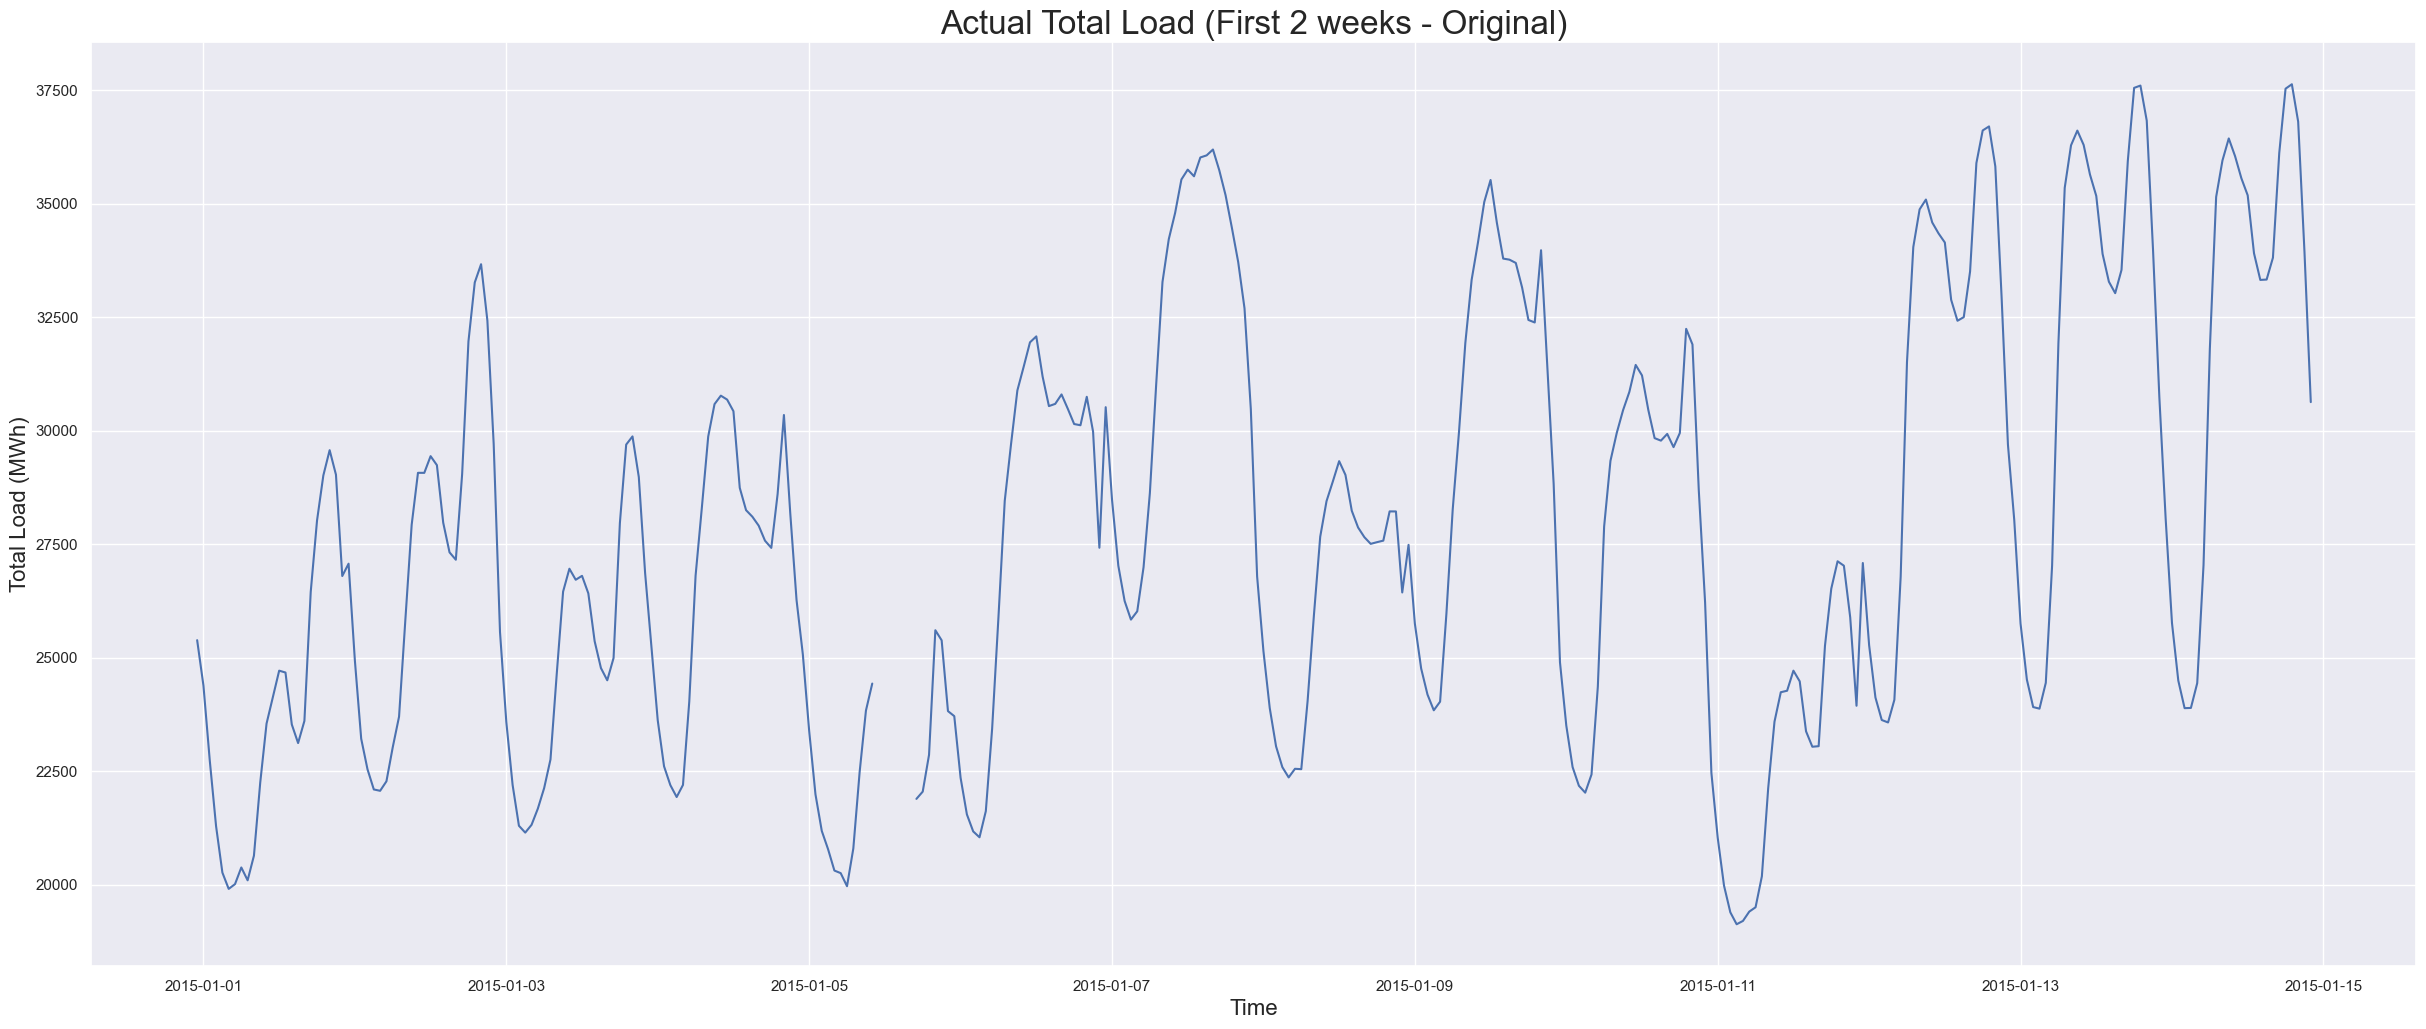

In [79]:
# Zoom into the plot of the hourly (actual) total load

ax = plot_series(df=df_energy, column='total load actual', ylabel='Total Load (MWh)',
                 title='Actual Total Load (First 2 weeks - Original)', end=24*7*2)
plt.show()

In [80]:
# Display the rows with null values

df_energy[df_energy.isnull().any(axis=1)].tail()

,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind onshore,total load actual,price day ahead,price actual
time,,,,,,,,,,,,,,,,,
2016-11-23 03:00:00+00:00,NaN,900.0,4838.0,4547.0,269.0,1413.0,795.0,435.0,5040.0,60.0,85.0,15.0,227.0,4598.0,23112.0,43.19,49.11
2017-11-14 11:00:00+00:00,0.0,0.0,10064.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,60.53,66.17
2017-11-14 18:00:00+00:00,0.0,0.0,12336.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,68.05,75.45
2018-06-11 16:00:00+00:00,331.0,506.0,7538.0,5360.0,300.0,1.0,1134.0,4258.0,5856.0,52.0,96.0,170.0,269.0,9165.0,NaN,69.87,64.93
2018-07-11 07:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,63.01,69.79


In [81]:
# Fill null values using interpolation

df_energy.interpolate(method='linear', limit_direction='forward', inplace=True, axis=0)

In [82]:
# Display the number of non-zero values in each column

print('Non-zero values in each column:\n', df_energy.astype(bool).sum(axis=0), sep='\n')

Non-zero values in each column:

generation biomass                             35060
generation fossil brown coal/lignite           24540
generation fossil gas                          35063
generation fossil hard coal                    35061
generation fossil oil                          35061
generation hydro pumped storage consumption    22450
generation hydro run-of-river and poundage     35061
generation hydro water reservoir               35061
generation nuclear                             35061
generation other                               35060
generation other renewable                     35061
generation solar                               35061
generation waste                               35061
generation wind onshore                        35061
total load actual                              35064
price day ahead                                35064
price actual                                   35064
dtype: int64


In [83]:
df_weather.head()

,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,2015-01-01 00:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
1,2015-01-01 01:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2,2015-01-01 02:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
3,2015-01-01 03:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
4,2015-01-01 04:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n


In [84]:
df_weather.describe().round(2)

,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id
count,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00
mean,289.62,288.33,291.09,1069.26,68.42,2.47,166.59,0.08,0.00,0.00,25.07,759.83
std,8.03,7.96,8.61,5969.63,21.90,2.10,116.61,0.40,0.01,0.22,30.77,108.73
min,262.24,262.24,262.24,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,200.00
25%,283.67,282.48,284.65,1013.00,53.00,1.00,55.00,0.00,0.00,0.00,0.00,800.00
50%,289.15,288.15,290.15,1018.00,72.00,2.00,177.00,0.00,0.00,0.00,20.00,800.00
75%,295.15,293.73,297.15,1022.00,87.00,4.00,270.00,0.00,0.00,0.00,40.00,801.00
max,315.60,315.15,321.15,1008371.00,100.00,133.00,360.00,12.00,2.32,21.50,100.00,804.00


In [85]:
# Print the type of each variable in df_weather

df_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178396 entries, 0 to 178395
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   dt_iso               178396 non-null  object 
 1   city_name            178396 non-null  object 
 2   temp                 178396 non-null  float64
 3   temp_min             178396 non-null  float64
 4   temp_max             178396 non-null  float64
 5   pressure             178396 non-null  int64  
 6   humidity             178396 non-null  int64  
 7   wind_speed           178396 non-null  int64  
 8   wind_deg             178396 non-null  int64  
 9   rain_1h              178396 non-null  float64
 10  rain_3h              178396 non-null  float64
 11  snow_3h              178396 non-null  float64
 12  clouds_all           178396 non-null  int64  
 13  weather_id           178396 non-null  int64  
 14  weather_main         178396 non-null  object 
 15  weather_descripti

In [86]:
def df_convert_dtypes(df, convert_from, convert_to):
    cols = df.select_dtypes(include=[convert_from]).columns
    for col in cols:
        df[col] = df[col].values.astype(convert_to)
    return df

In [87]:
# Convert columns with int64 type values to float64 type

df_weather = df_convert_dtypes(df_weather, np.int64, np.float64)

In [88]:

# Convert dt_iso to datetime type, rename it and set it as index

df_weather['time'] = pd.to_datetime(df_weather['dt_iso'], utc=True, infer_datetime_format=True)
df_weather = df_weather.drop(['dt_iso'], axis=1)
df_weather = df_weather.set_index('time')

In [89]:
# Display average weather features grouped by each city

mean_weather_by_city = df_weather.groupby('city_name').mean(numeric_only=True)
mean_weather_by_city

,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id
city_name,,,,,,,,,,,,
Barcelona,289.848248,288.594704,291.021987,1284.010486,73.994221,2.786588,187.188043,0.117079,0.000327,0.000000,23.229648,760.917465
Bilbao,286.378489,284.916661,288.036687,1017.567439,79.089455,1.957470,159.883536,0.123493,0.001034,0.023455,43.960697,723.943228
Madrid,288.061071,286.824877,289.155600,1011.838448,59.776932,2.441696,173.293159,0.055083,0.000129,0.000029,22.397028,762.260264
Seville,293.105431,291.184103,295.962431,1018.504711,64.140732,2.483787,151.757179,0.045392,0.000180,0.000000,14.748770,771.409849
Valencia,290.780780,290.222277,291.355025,1015.973794,65.145113,2.692815,160.753820,0.035924,0.000226,0.000154,20.820999,781.228283


In [90]:
# Find NaNs and duplicates in df_weather

print('There are {} missing values or NaNs in df_weather.'
      .format(df_weather.isnull().values.sum()))

temp_weather = df_weather.duplicated(keep='first').sum()

print('There are {} duplicate rows in df_weather based on all columns.'
      .format(temp_weather))

There are 0 missing values or NaNs in df_weather.
There are 8622 duplicate rows in df_weather based on all columns.


In [91]:
# Display the number of rows in each dataframe

print('There are {} observations in df_energy.'.format(df_energy.shape[0]))

cities = df_weather['city_name'].unique()
grouped_weather = df_weather.groupby('city_name')

for city in cities:
    print('There are {} observations in df_weather'
          .format(grouped_weather.get_group('{}'.format(city)).shape[0]), 
          'about city: {}.'.format(city))

There are 35064 observations in df_energy.
There are 35145 observations in df_weather about city: Valencia.
There are 36267 observations in df_weather about city: Madrid.
There are 35951 observations in df_weather about city: Bilbao.
There are 35476 observations in df_weather about city:  Barcelona.
There are 35557 observations in df_weather about city: Seville.


In [92]:
# Create df_weather_2 and drop duplicate rows in df_weather

df_weather_2 = df_weather.reset_index().drop_duplicates(subset=['time', 'city_name'], 
                                                        keep='last').set_index('time')

df_weather = df_weather.reset_index().drop_duplicates(subset=['time', 'city_name'],
                                                      keep='first').set_index('time')

In [93]:
# Display the number of rows in each dataframe again

print('There are {} observations in df_energy.'.format(df_energy.shape[0]))

grouped_weather = df_weather.groupby('city_name')

for city in cities:
    print('There are {} observations in df_weather'
          .format(grouped_weather.get_group('{}'.format(city)).shape[0]), 
          'about city: {}.'.format(city))

There are 35064 observations in df_energy.
There are 35064 observations in df_weather about city: Valencia.
There are 35064 observations in df_weather about city: Madrid.
There are 35064 observations in df_weather about city: Bilbao.
There are 35064 observations in df_weather about city:  Barcelona.
There are 35064 observations in df_weather about city: Seville.


In [94]:
# Display all the unique values in the column 'weather_description'

weather_description_unique = df_weather['weather_description'].unique()
weather_description_unique

array(['sky is clear', 'few clouds', 'scattered clouds', 'broken clouds',
       'overcast clouds', 'light rain', 'moderate rain',
       'heavy intensity rain', 'mist', 'heavy intensity shower rain',
       'shower rain', 'very heavy rain', 'thunderstorm with heavy rain',
       'thunderstorm with light rain', 'proximity thunderstorm',
       'thunderstorm', 'light intensity shower rain',
       'light intensity drizzle', 'thunderstorm with rain', 'fog',
       'smoke', 'drizzle', 'heavy intensity drizzle', 'haze',
       'proximity shower rain', 'light snow', 'rain and snow',
       'light rain and snow', 'snow', 'sleet', 'rain and drizzle',
       'light intensity drizzle rain', 'light shower snow',
       'proximity moderate rain', 'ragged shower rain', 'heavy snow',
       'sand dust whirls', 'proximity drizzle', 'dust',
       'light thunderstorm', 'squalls'], dtype=object)

In [95]:
# Display all the unique values in the column 'weather_main'

weather_main_unique = df_weather['weather_main'].unique()
weather_main_unique

array(['clear', 'clouds', 'rain', 'mist', 'thunderstorm', 'drizzle',
       'fog', 'smoke', 'haze', 'snow', 'dust', 'squall'], dtype=object)

In [96]:
# Display all the unique values in the column 'weather_id'

weather_id_unique = df_weather['weather_id'].unique()
weather_id_unique

array([800., 801., 802., 803., 804., 500., 501., 502., 701., 522., 521.,
       503., 202., 200., 211., 520., 300., 201., 741., 711., 301., 302.,
       721., 600., 616., 615., 601., 611., 311., 310., 620., 531., 602.,
       731., 761., 210., 771.])

In [97]:
def encode_and_display_r2_score(df_1, df_2, column, categorical=False):
    s1 = df_1[column].copy()
    s2 = df_2[column].copy()

    if categorical:
        le = LabelEncoder()
        le.fit(pd.concat([s1.astype(str), s2.astype(str)], axis=0))
        s1 = le.transform(s1.astype(str))
        s2 = le.transform(s2.astype(str))

    r2 = r2_score(s1, s2)
    msg = f"R-Squared score of {column} is {r2:.3f}"
    print(msg, flush=True)
    return r2

encode_and_display_r2_score(df_weather, df_weather_2, "weather_description", categorical=True)
encode_and_display_r2_score(df_weather, df_weather_2, "weather_main", categorical=True)
encode_and_display_r2_score(df_weather, df_weather_2, "weather_id", categorical=False)


R-Squared score of weather_description is 0.986
R-Squared score of weather_main is 0.963
R-Squared score of weather_id is 0.921


0.9205784928822044

In [98]:
# Drop columns with qualitative weather information
df_weather = df_weather.drop(['weather_main', 'weather_id', 
                              'weather_description', 'weather_icon'], axis=1)

In [99]:
# Display the R-squared for all the columns in df_weather and df_weather_2

df_weather_cols = df_weather.columns.drop('city_name')

for col in df_weather_cols:
    encode_and_display_r2_score(df_weather, df_weather_2, col)

R-Squared score of temp is 1.000
R-Squared score of temp_min is 1.000
R-Squared score of temp_max is 1.000
R-Squared score of pressure is 1.000
R-Squared score of humidity is 1.000
R-Squared score of wind_speed is 1.000
R-Squared score of wind_deg is 1.000
R-Squared score of rain_1h is 1.000
R-Squared score of rain_3h is 1.000
R-Squared score of snow_3h is 1.000
R-Squared score of clouds_all is 1.000


In [100]:
# Display the number of duplicates in df_weather

temp_weather = df_weather.reset_index().duplicated(subset=['time', 'city_name'], 
                                                   keep='first').sum()
print('There are {} duplicate rows in df_weather ' \
      'based on all columns except "time" and "city_name".'.format(temp_weather))

There are 0 duplicate rows in df_weather based on all columns except "time" and "city_name".


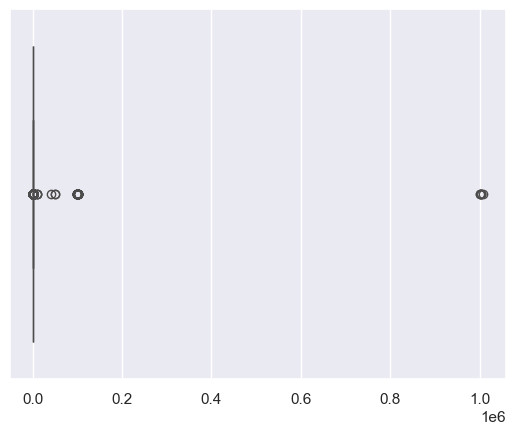

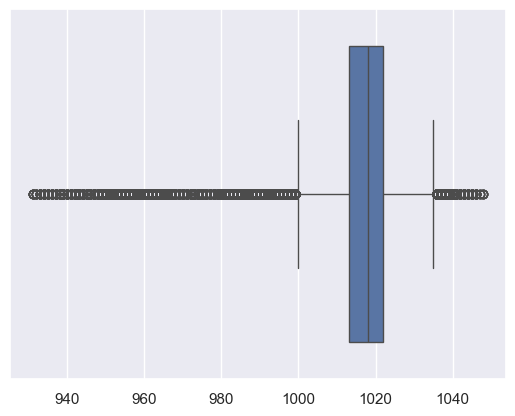

In [101]:
# Check for outliers in 'pressure' column

sns.boxplot(x=df_weather["pressure"].to_numpy())
plt.show()


# Replace outliers in 'pressure' with NaNs

df_weather.loc[df_weather.pressure > 1051, 'pressure'] = np.nan
df_weather.loc[df_weather.pressure < 931, 'pressure'] = np.nan

# Check for outliers in 'pressure' column again

sns.boxplot(x=df_weather["pressure"].to_numpy())
plt.show()


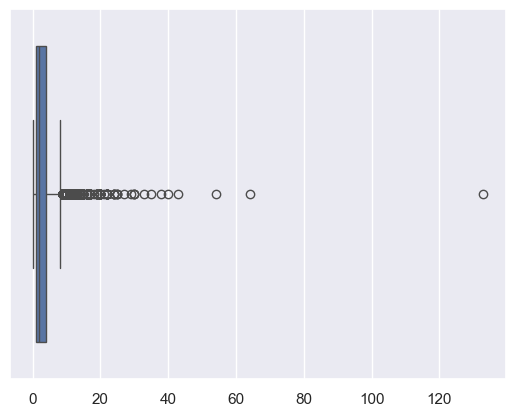

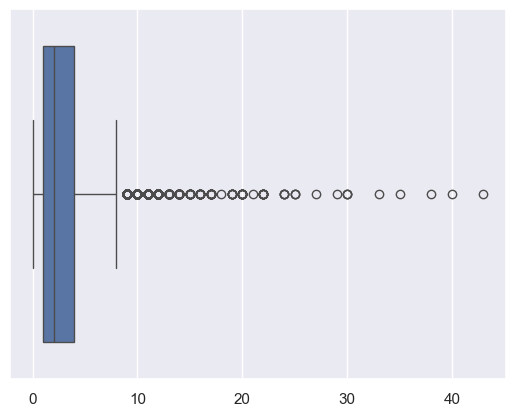

In [102]:
# Check for outliers in 'wind_speed' column

sns.boxplot(x=df_weather["wind_speed"].to_numpy())
plt.show()

# Replace outliers in 'wind_speed' with NaNs

df_weather.loc[df_weather.wind_speed > 50, 'wind_speed'] = np.nan

# Check for outliers in 'wind_speed' column again

sns.boxplot(x=df_weather["wind_speed"].to_numpy())
plt.show()



In [103]:
# Fill null values using interpolation

df_weather.interpolate(method='linear', limit_direction='forward', inplace=True, axis=0)

In [104]:
# Split the df_weather into 5 dataframes (one for each city)

df_1, df_2, df_3, df_4, df_5 = [x for _, x in df_weather.groupby('city_name')]
dfs = [df_1, df_2, df_3, df_4, df_5]

# Merge all dataframes into the final dataframe

df_final = df_energy

for df in dfs:
    city = df['city_name'].unique()
    city_str = str(city).replace("'", "").replace('[', '').replace(']', '').replace(' ', '')
    df = df.add_suffix('_{}'.format(city_str))
    df_final = df_final.merge(df, on=['time'], how='outer')
    df_final = df_final.drop('city_name_{}'.format(city_str), axis=1)
    
df_final.columns



Index(['generation biomass', 'generation fossil brown coal/lignite',
       'generation fossil gas', 'generation fossil hard coal',
       'generation fossil oil', 'generation hydro pumped storage consumption',
       'generation hydro run-of-river and poundage',
       'generation hydro water reservoir', 'generation nuclear',
       'generation other', 'generation other renewable', 'generation solar',
       'generation waste', 'generation wind onshore', 'total load actual',
       'price day ahead', 'price actual', 'temp_Barcelona',
       'temp_min_Barcelona', 'temp_max_Barcelona', 'pressure_Barcelona',
       'humidity_Barcelona', 'wind_speed_Barcelona', 'wind_deg_Barcelona',
       'rain_1h_Barcelona', 'rain_3h_Barcelona', 'snow_3h_Barcelona',
       'clouds_all_Barcelona', 'temp_Bilbao', 'temp_min_Bilbao',
       'temp_max_Bilbao', 'pressure_Bilbao', 'humidity_Bilbao',
       'wind_speed_Bilbao', 'wind_deg_Bilbao', 'rain_1h_Bilbao',
       'rain_3h_Bilbao', 'snow_3h_Bilbao', 'clo

In [105]:
# Display the number of NaNs and duplicates in the final dataframe

print('There are {} missing values or NaNs in df_final.'
      .format(df_final.isnull().values.sum()))

temp_final = df_final.duplicated(keep='first').sum()

print('\nThere are {} duplicate rows in df_energy based on all columns.'
      .format(temp_final))

There are 0 missing values or NaNs in df_final.

There are 0 duplicate rows in df_energy based on all columns.


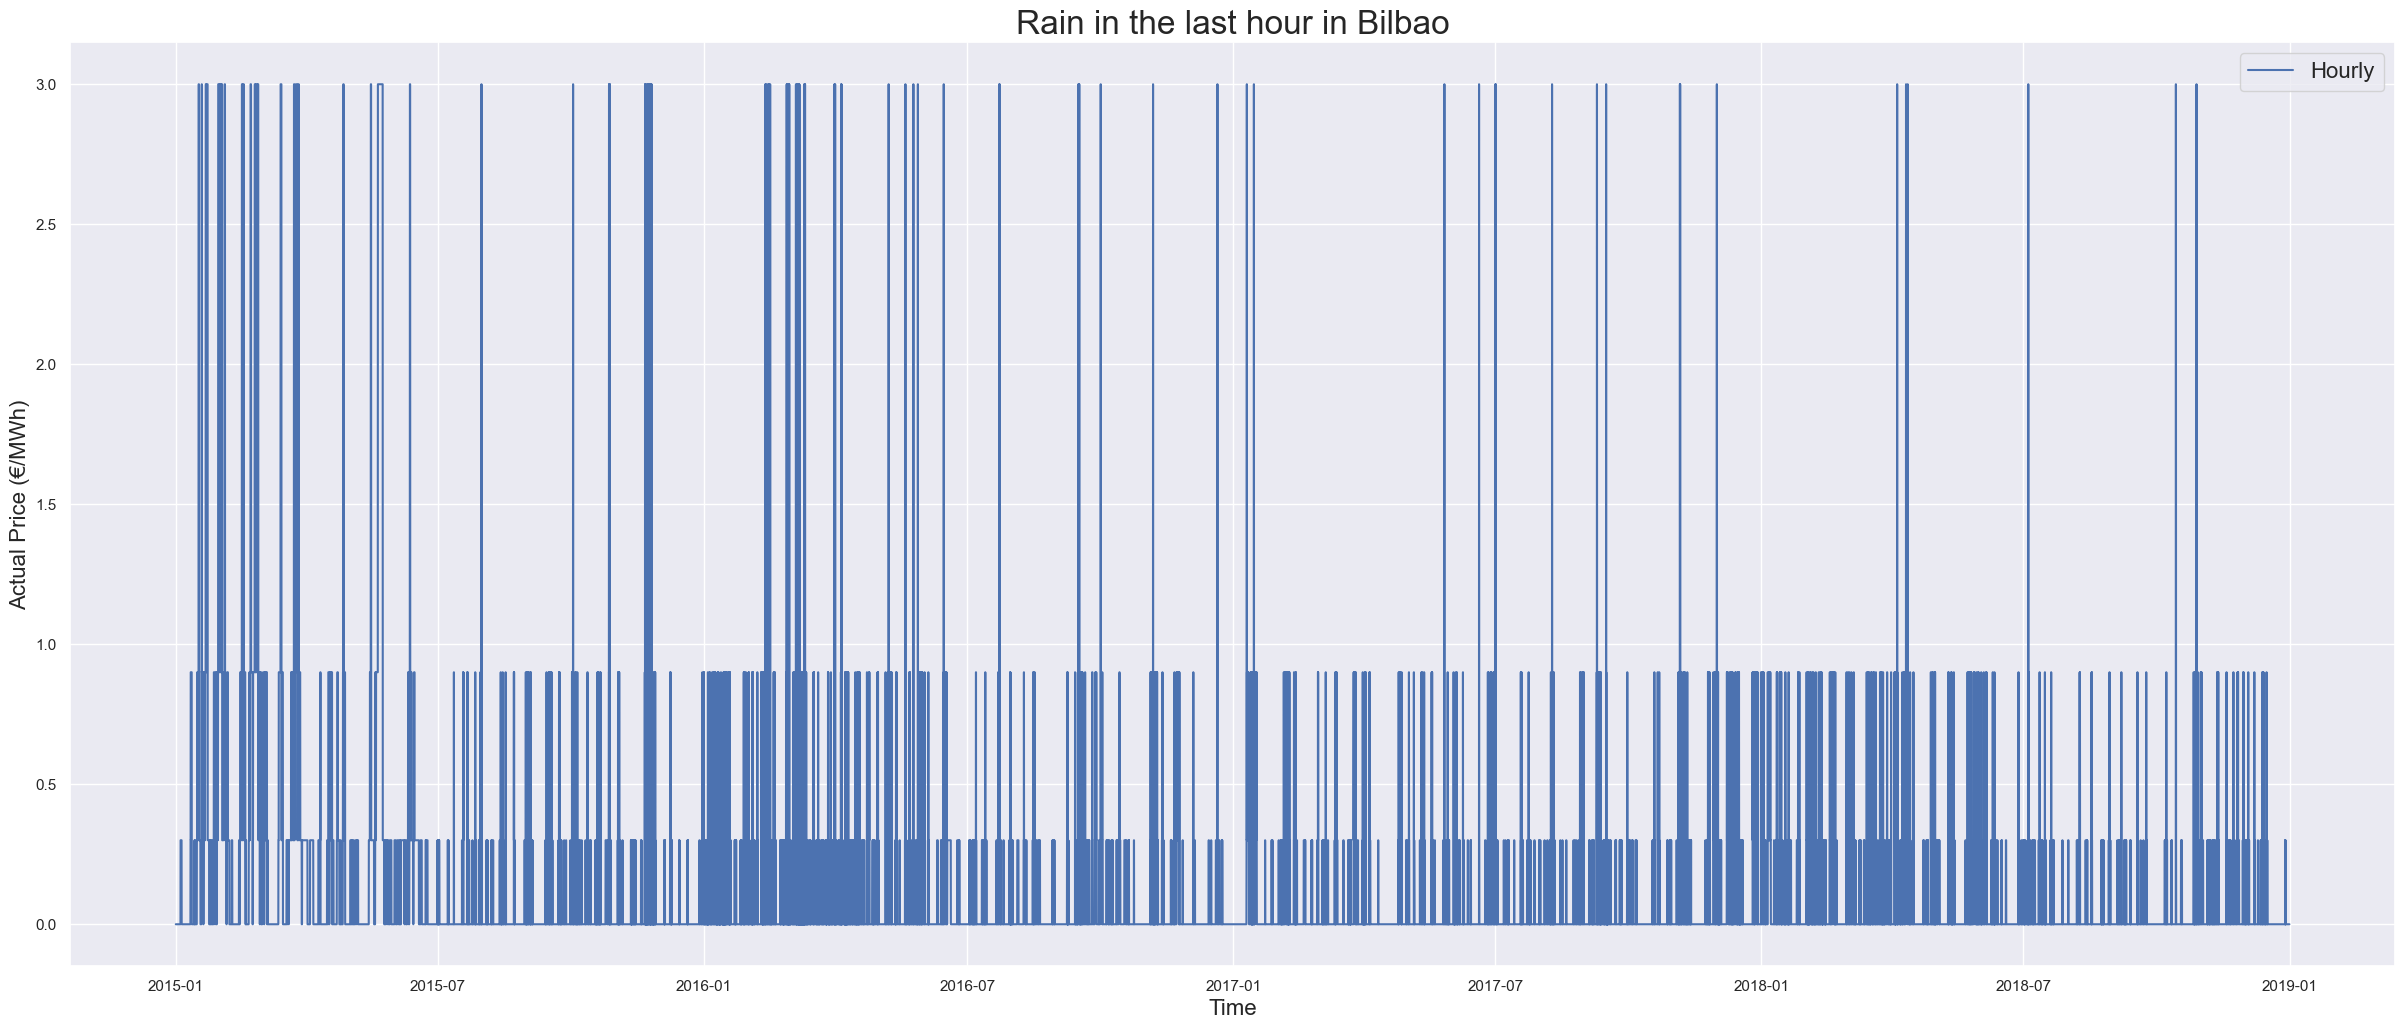

In [106]:
# Plot the 'rain_1h' for Bilbao

ax = plot_series(df_final, 'rain_1h_Bilbao', 
                 label='Hourly', ylabel='Actual Price (€/MWh)',
                 title='Rain in the last hour in Bilbao')
plt.show()

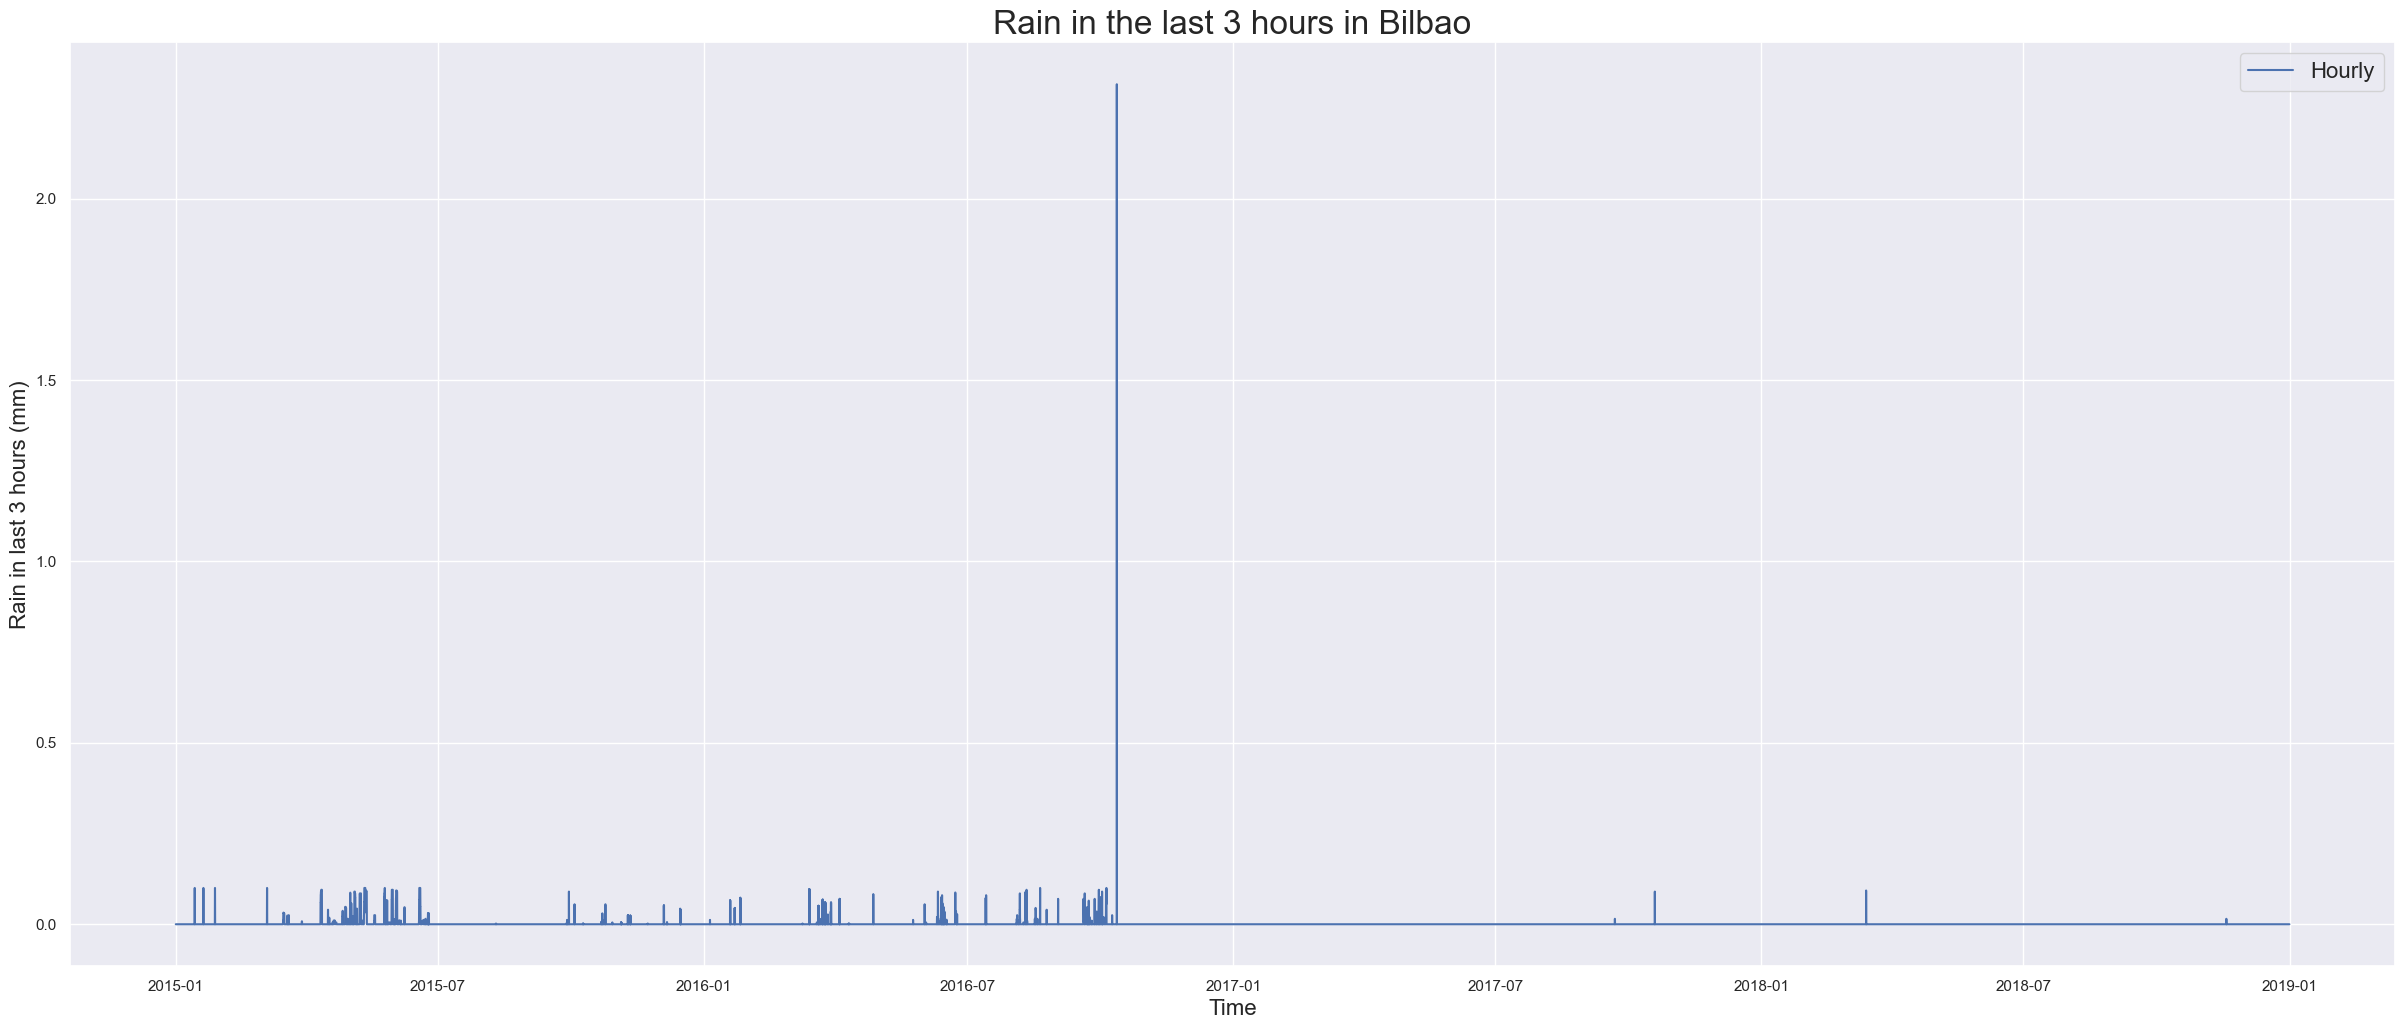

In [107]:
# Plot the 'rain_3h' for Bilbao

ax = plot_series(df_final, 'rain_3h_Bilbao', 
                 label='Hourly', ylabel='Rain in last 3 hours (mm)',
                 title='Rain in the last 3 hours in Bilbao')
plt.show()

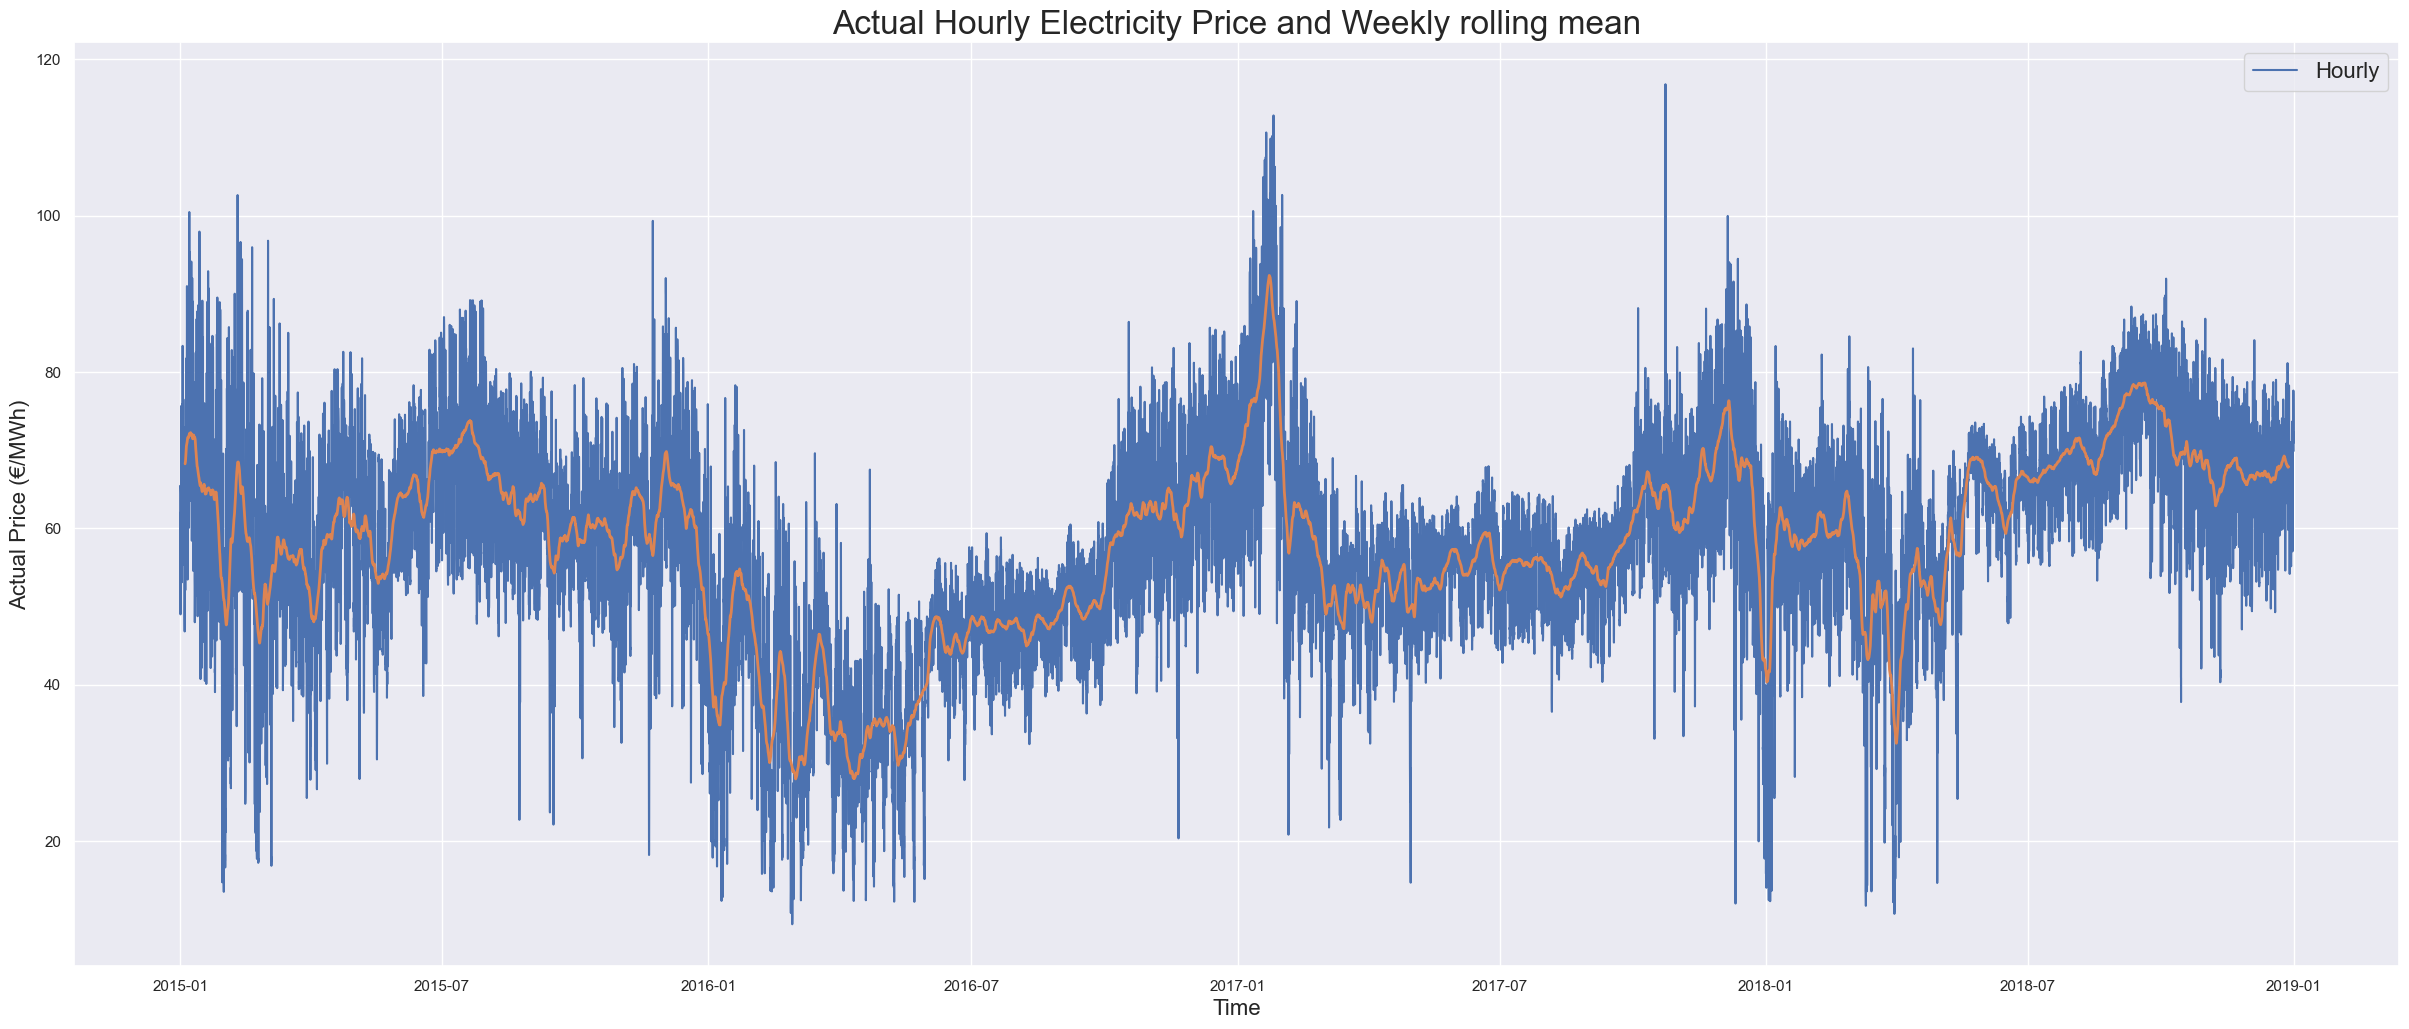

In [108]:
cities = ['Barcelona', 'Bilbao', 'Madrid', 'Seville', 'Valencia']

for city in cities:
    df_final = df_final.drop(['rain_3h_{}'.format(city)], axis=1)

# Plot the hourly actual electricity price, along with the weekly rolling mean

rolling = df_final['price actual'].rolling(24*7, center=True).mean()
ax = plot_series(df_final, 'price actual', label='Hourly', ylabel='Actual Price (€/MWh)',
                 title='Actual Hourly Electricity Price and Weekly rolling mean')
ax.plot(rolling, linestyle='-', linewidth=2, label='Weekly rolling mean')
plt.show()



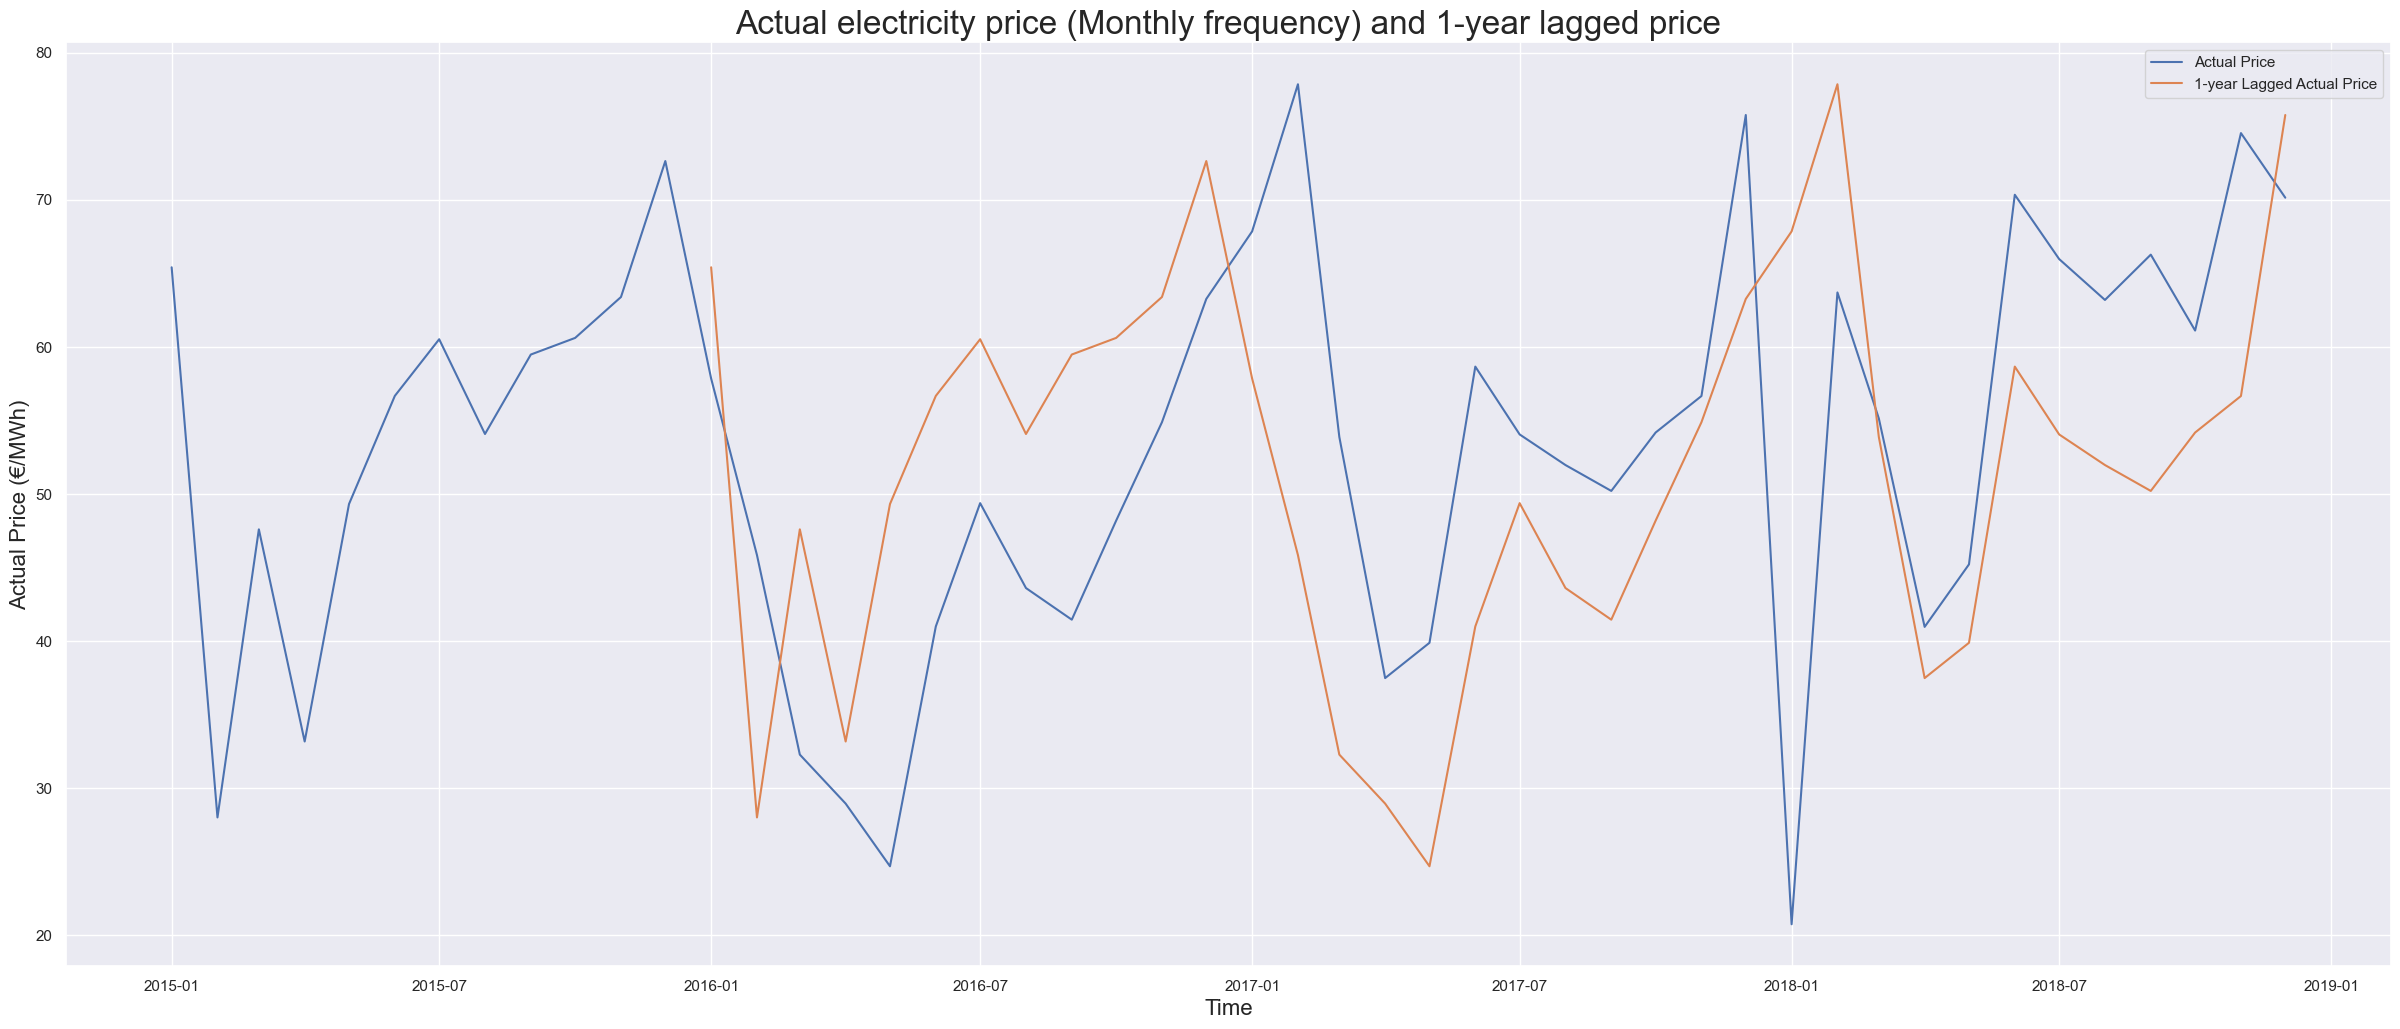

In [109]:
# Plot the electricity price (monthly frequence) along with its 1-year lagged series

monthly_price = df_final['price actual'].asfreq('M')
ax = plot_series(series=monthly_price, ylabel='Actual Price (€/MWh)',
                 title='Actual electricity price (Monthly frequency) and 1-year lagged price')
shifted = df_final['price actual'].asfreq('M').shift(12)
ax.plot(shifted, label='Hourly')
ax.legend(['Actual Price', '1-year Lagged Actual Price'])
plt.show()

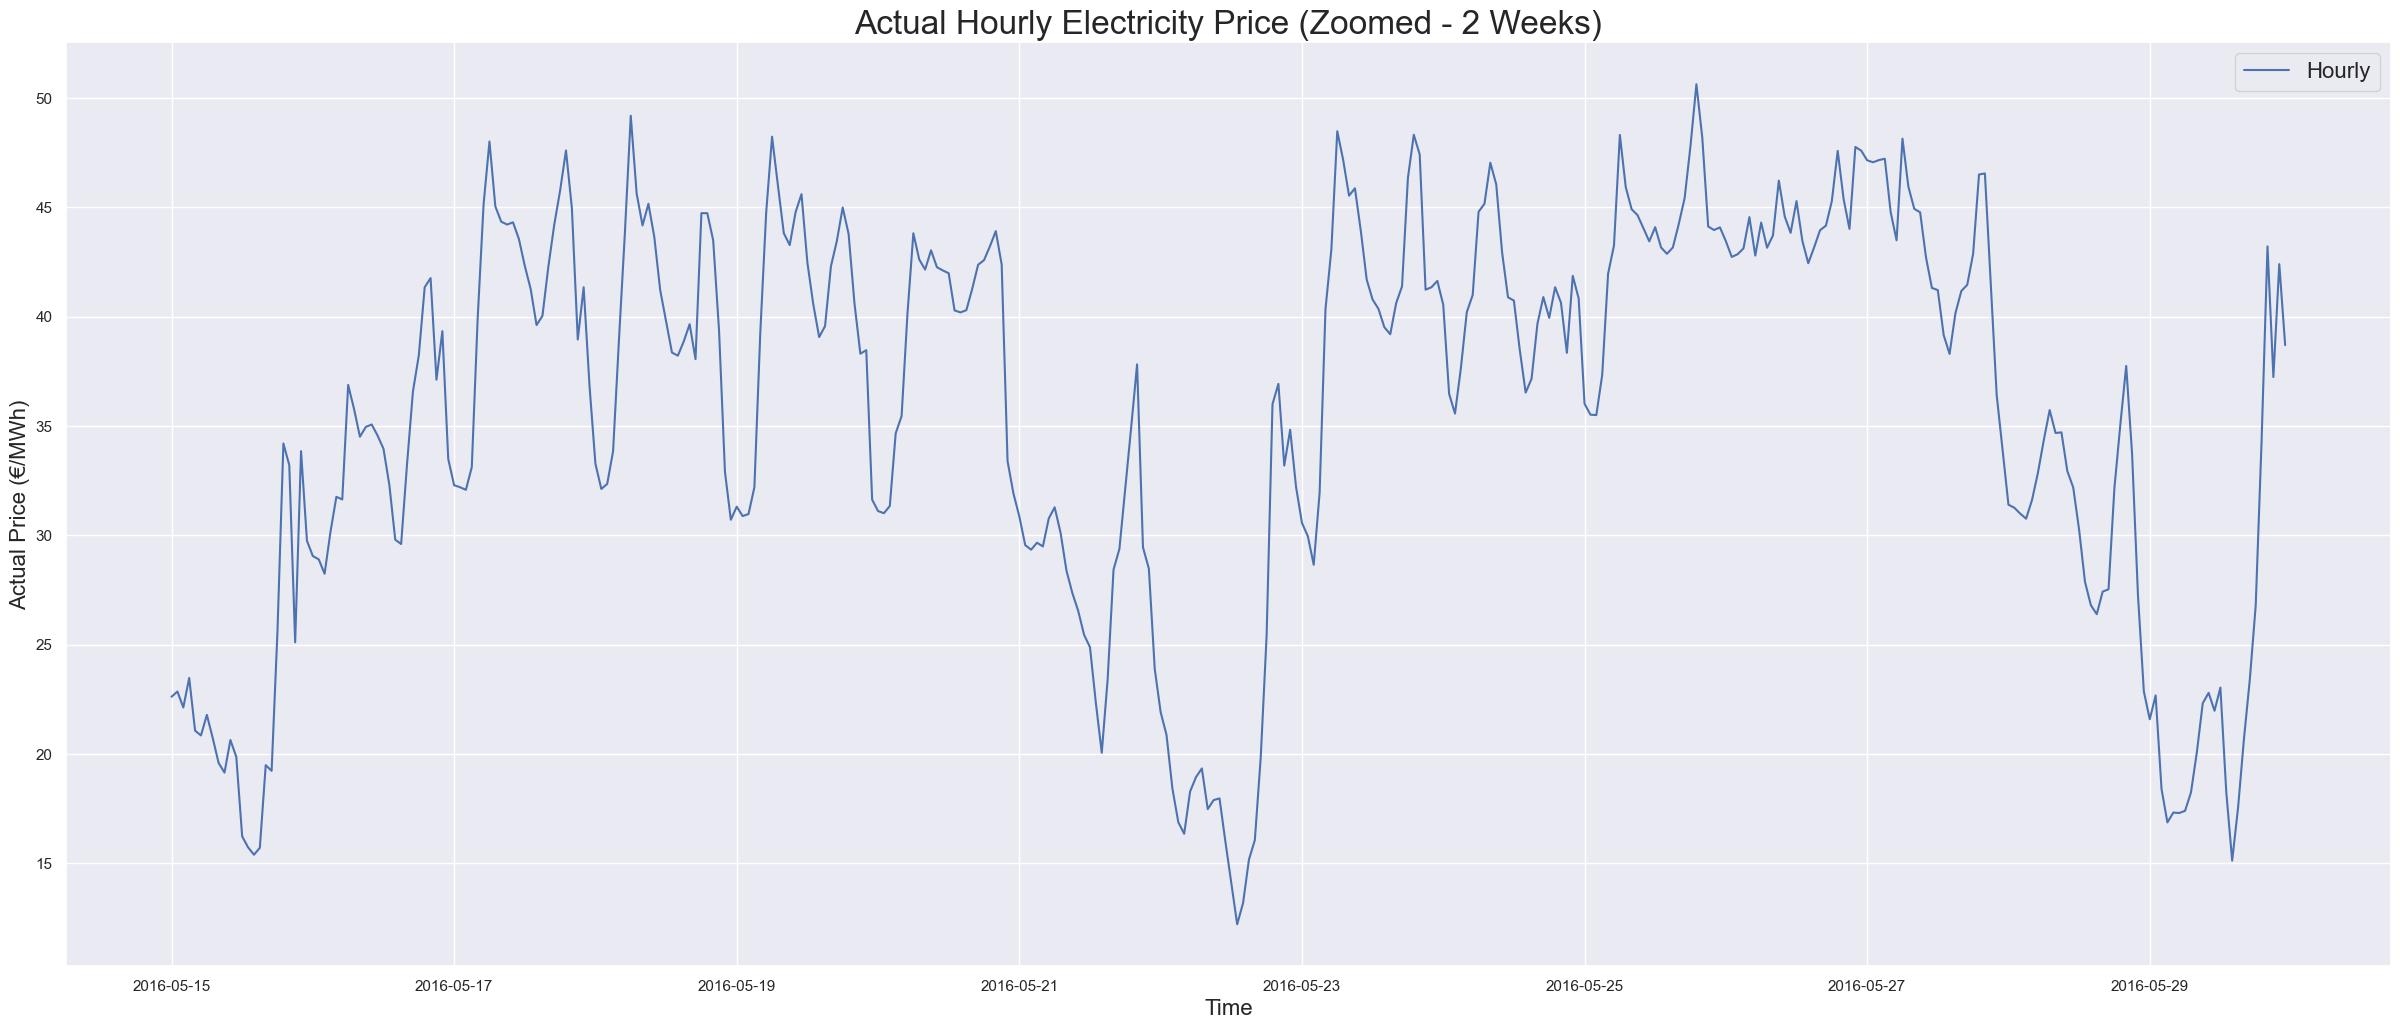

In [110]:
# Plot the actual electricity price at a daily/weekly scale

ax = plot_series(df_final, 'price actual', label='Hourly', ylabel='Actual Price (€/MWh)',
                 start=1 + 24 * 500, end=1 + 24 * 515,
                 title='Actual Hourly Electricity Price (Zoomed - 2 Weeks)')
plt.show()

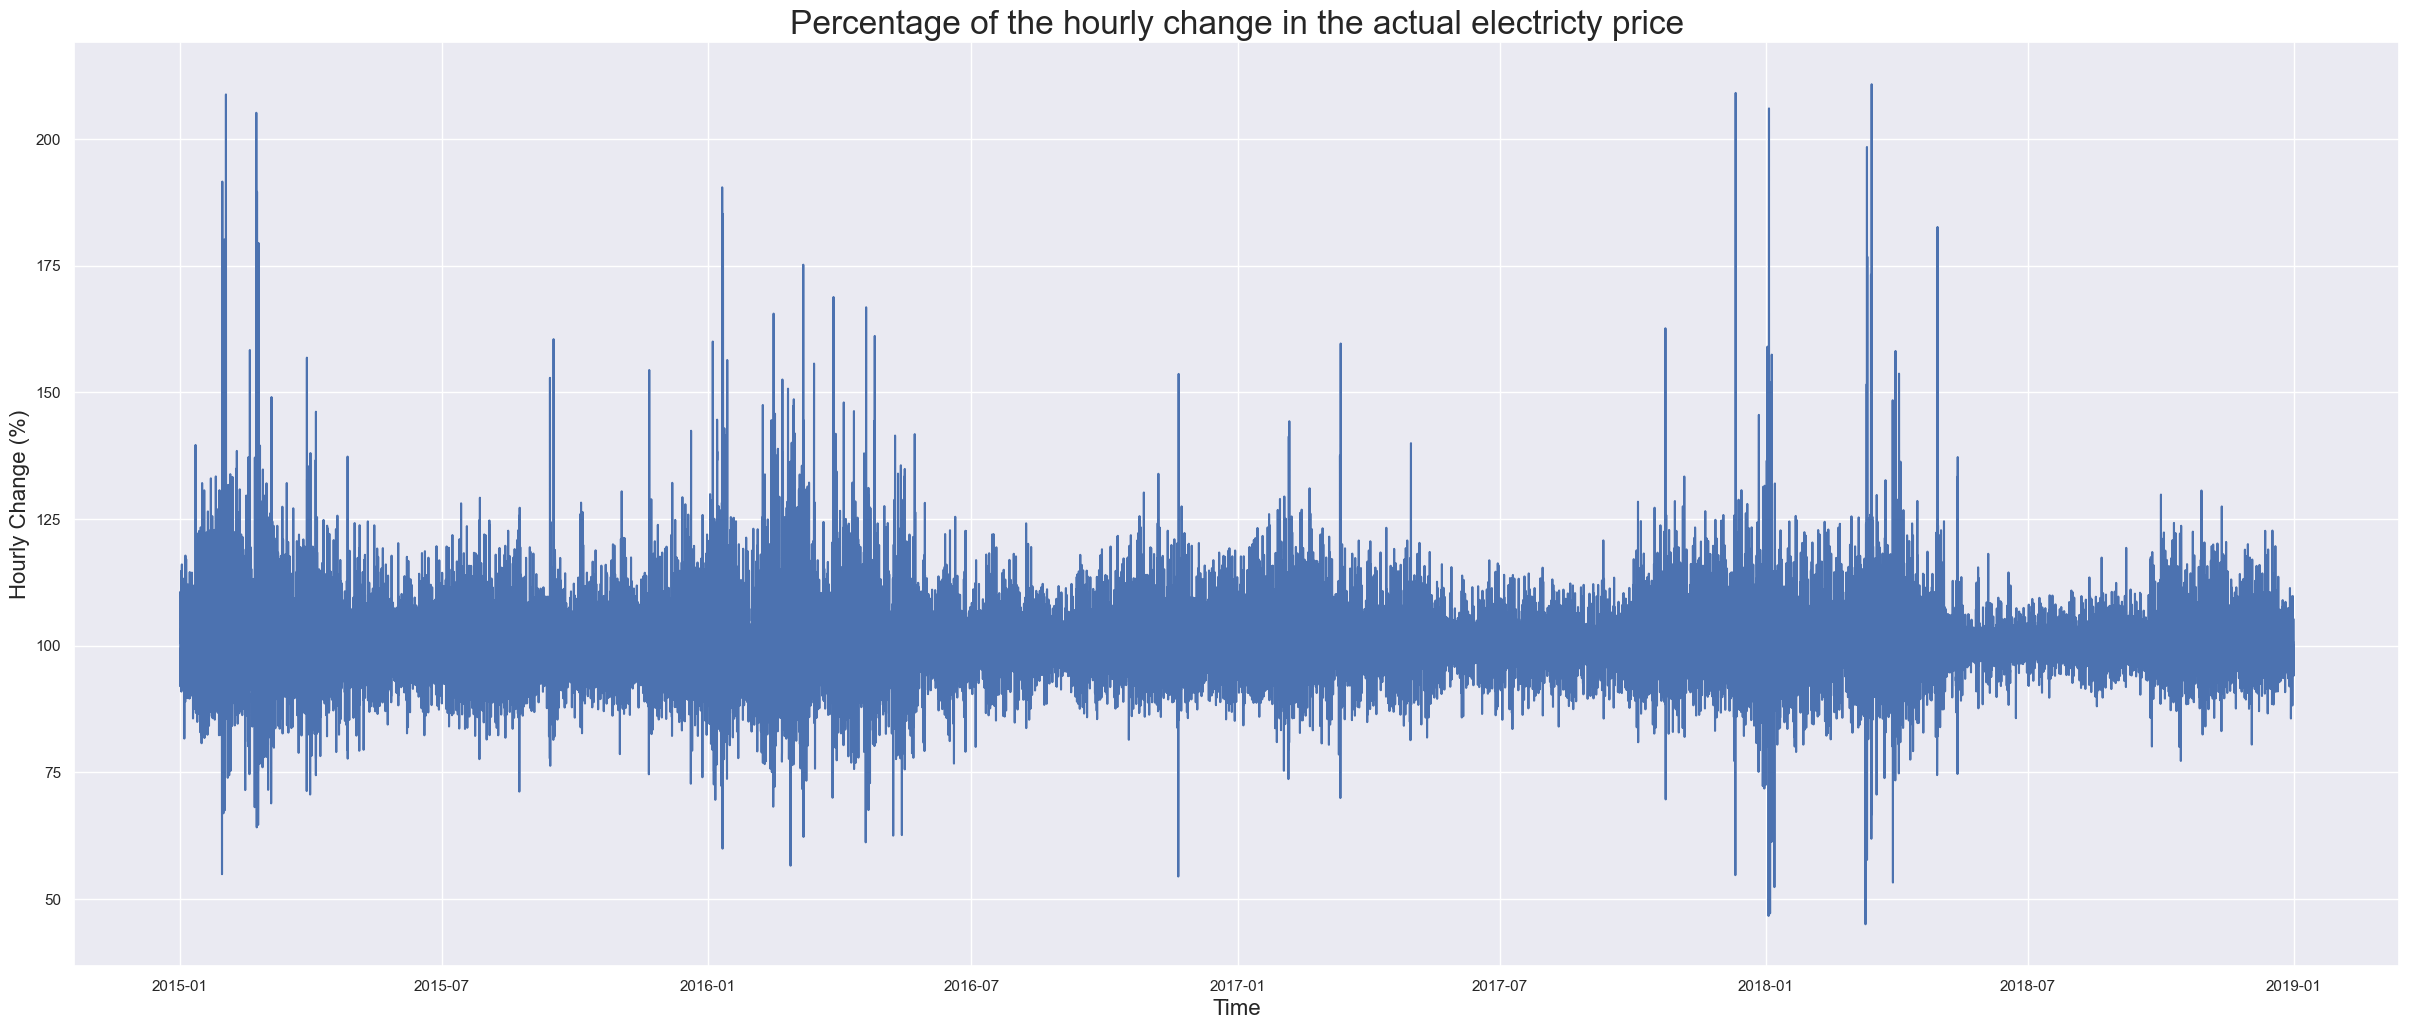

In [111]:
# Plot the percentage of the hourly change in the actual electricity price

change = df_energy['price actual'].div(df_energy['price actual'].shift(1)).mul(100)
ax = plot_series(series=change, ylabel='Hourly Change (%)', 
                 title='Percentage of the hourly change in the actual electricty price')
plt.show()

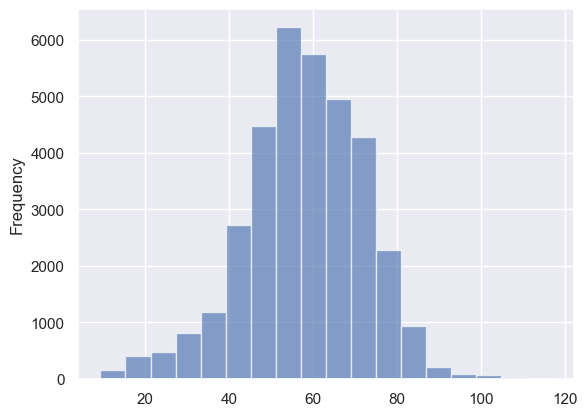

In [112]:
# Plot the histogram of the actual electricity price

ax = df_energy['price actual'].plot.hist(bins=18, alpha=0.65)

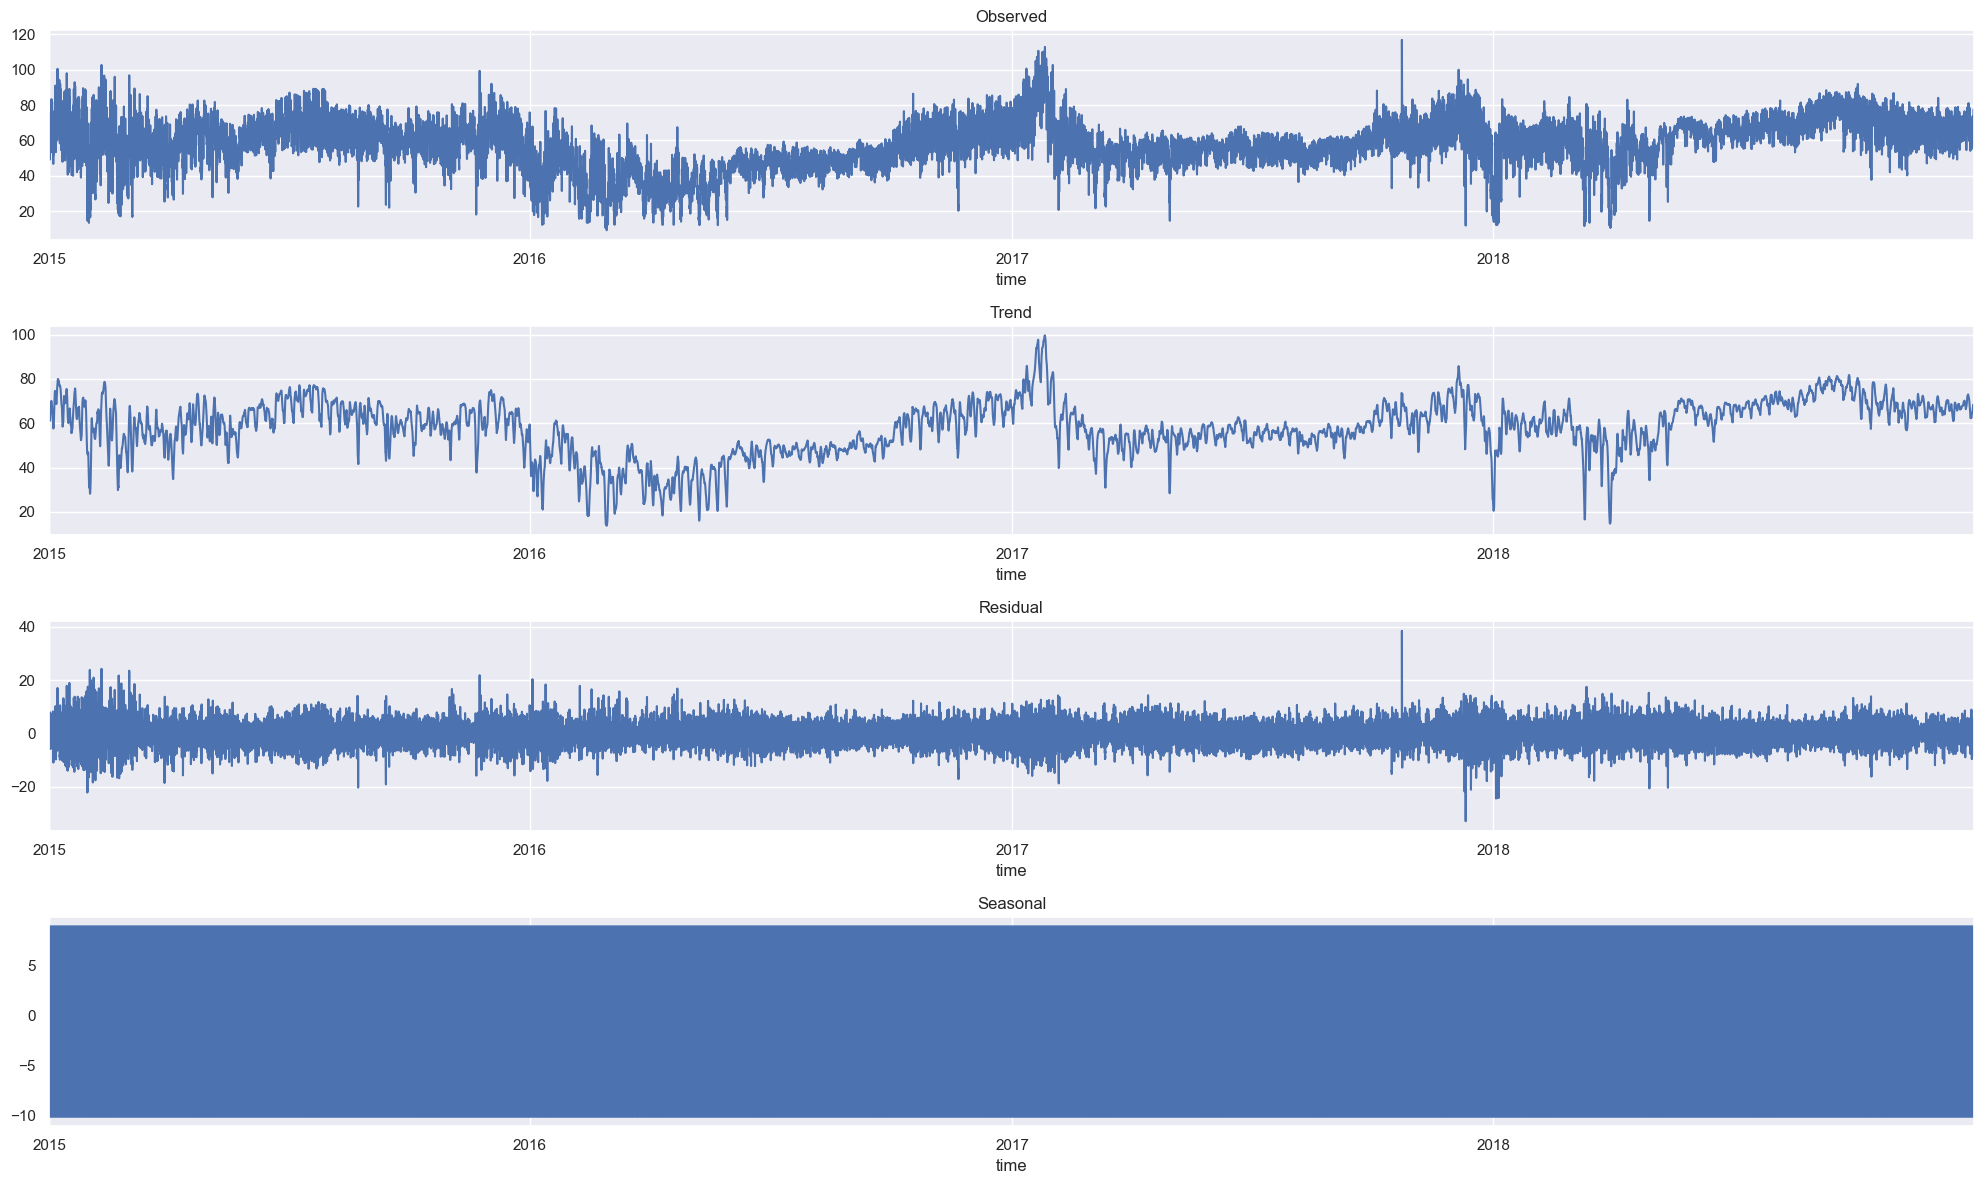

In [113]:
# Decompose the electricity price time series

res = sm.tsa.seasonal_decompose(df_energy['price actual'], model='additive')

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(20, 12))
res.observed.plot(ax=ax1, title='Observed')
res.trend.plot(ax=ax2, title='Trend')
res.resid.plot(ax=ax3, title='Residual')
res.seasonal.plot(ax=ax4, title='Seasonal')
plt.tight_layout()
plt.show()

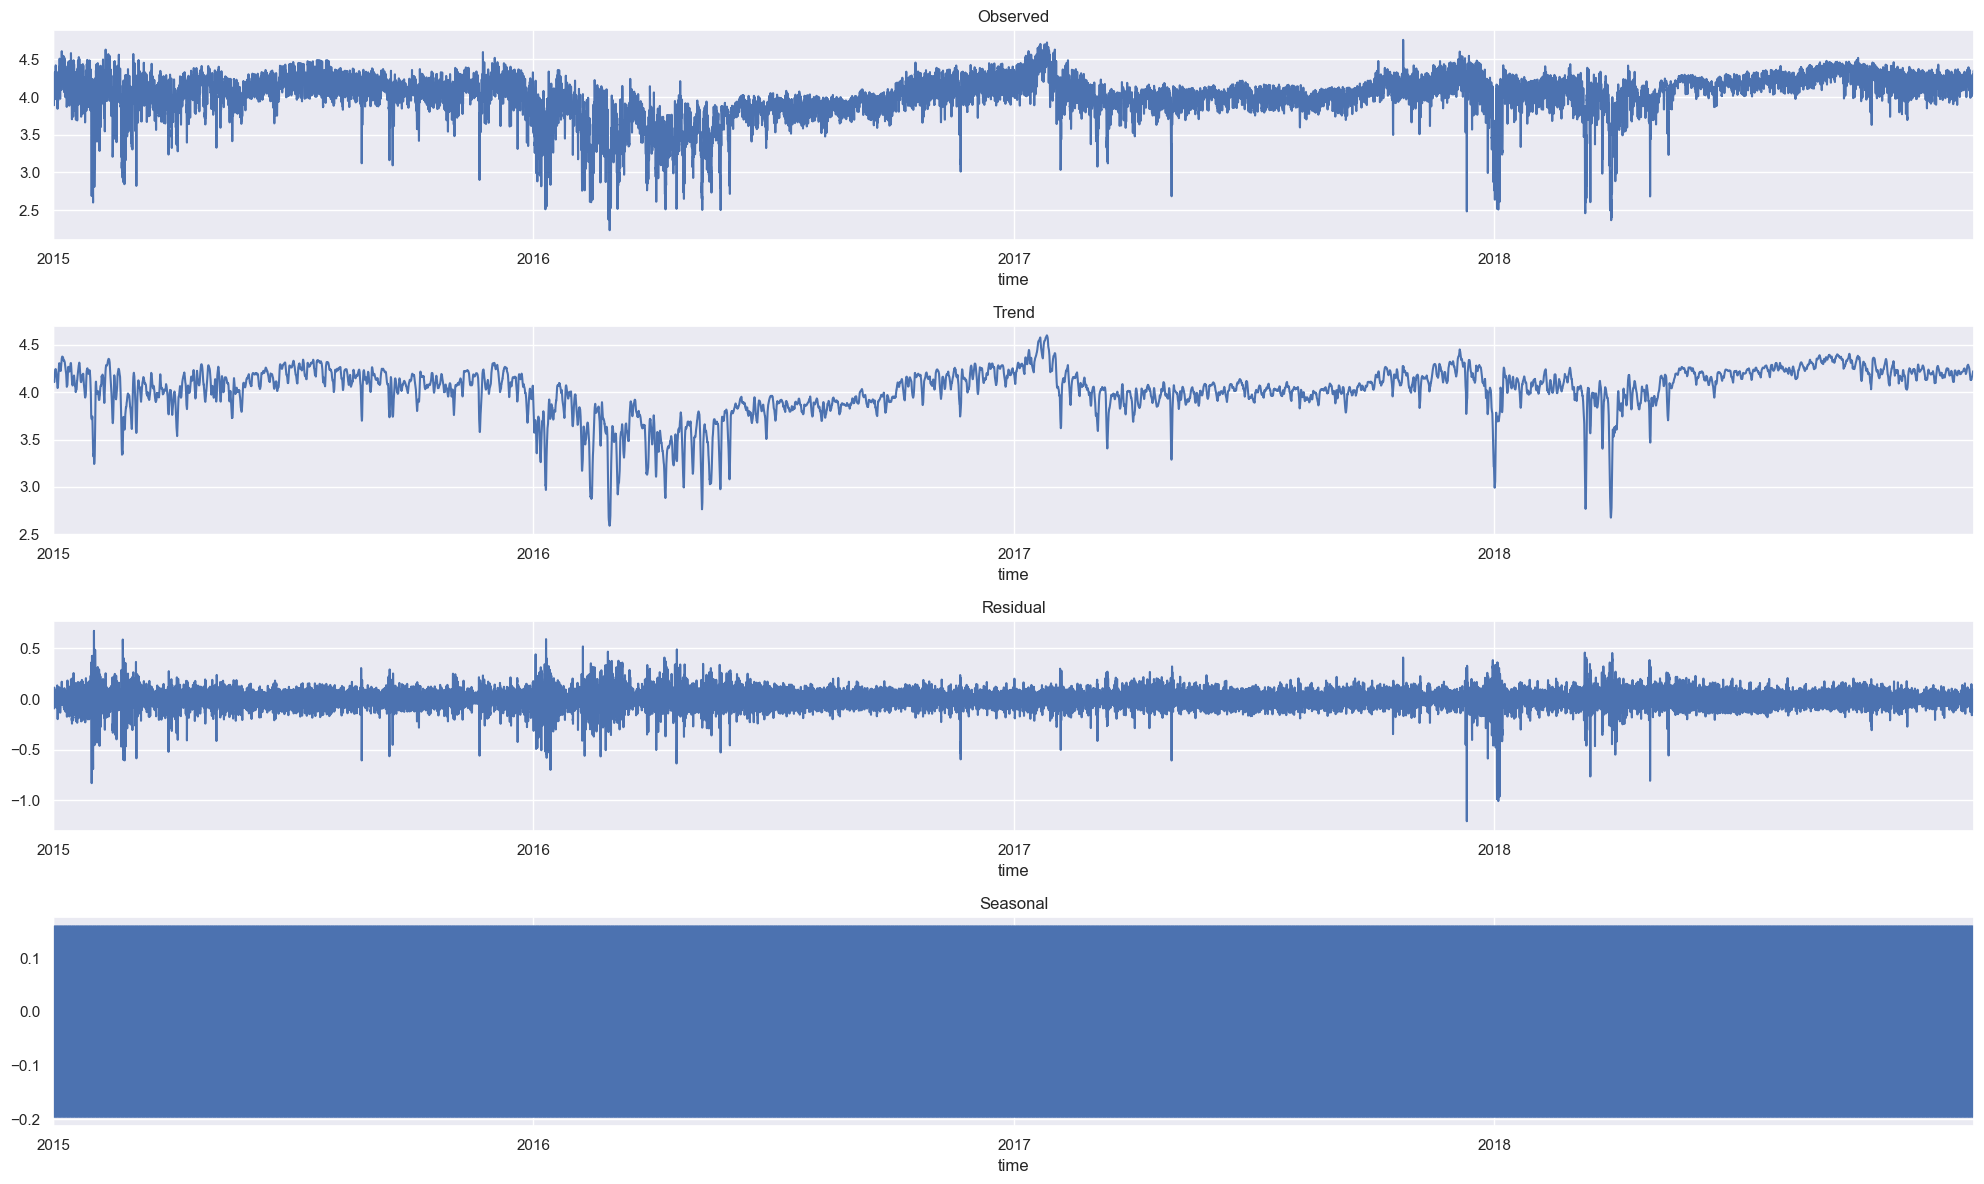

In [114]:
# Decompose the log electricity price time-series

res = sm.tsa.seasonal_decompose(np.log(df_energy['price actual']), model='additive')

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(20, 12))
res.observed.plot(ax=ax1, title='Observed')
res.trend.plot(ax=ax2, title='Trend')
res.resid.plot(ax=ax3, title='Residual')
res.seasonal.plot(ax=ax4, title='Seasonal')
plt.tight_layout()
plt.show()

In [115]:
y = df_final['price actual']
adf_test = adfuller(y, regression='c')
print('ADF Statistic: {:.6f}\np-value: {:.6f}\n#Lags used: {}'
      .format(adf_test[0], adf_test[1], adf_test[2]))
for key, value in adf_test[4].items():
    print('Critical Value ({}): {:.6f}'.format(key, value))

ADF Statistic: -9.147016
p-value: 0.000000
#Lags used: 50
Critical Value (1%): -3.430537
Critical Value (5%): -2.861623
Critical Value (10%): -2.566814


In [116]:
from statsmodels.tsa.stattools import kpss

kpss_test = kpss(y, regression='c', nlags='legacy')

print(
    'KPSS Statistic: {:.6f}\n'
    'p-value: {:.6f}\n'
    '#Lags used: {}'
    .format(kpss_test[0], kpss_test[1], kpss_test[2])
)

for key, value in kpss_test[3].items():
    print(f'Critical Value ({key}): {value:.6f}')


KPSS Statistic: 7.957007
p-value: 0.010000
#Lags used: 52
Critical Value (10%): 0.347000
Critical Value (5%): 0.463000
Critical Value (2.5%): 0.574000
Critical Value (1%): 0.739000


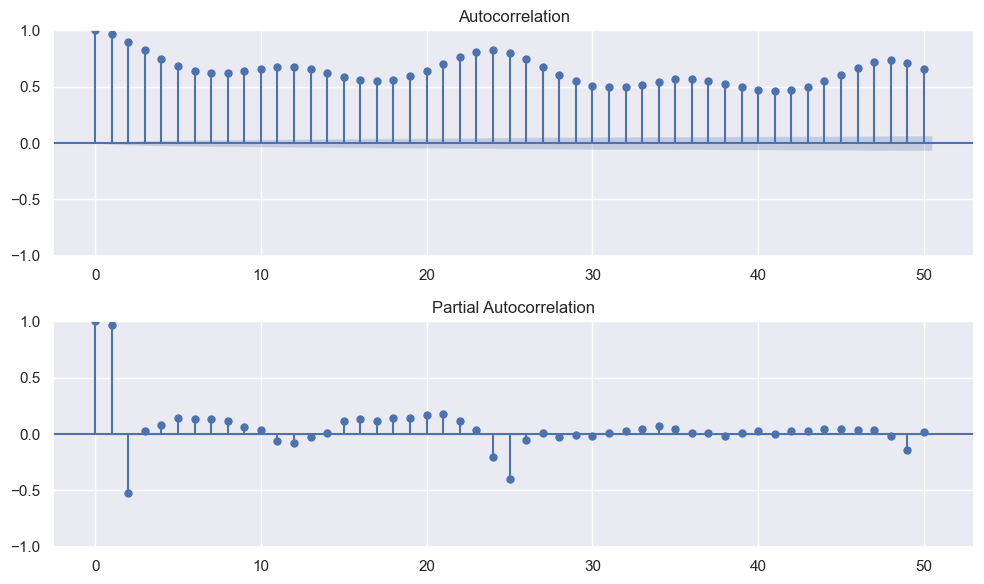

In [117]:
# Plot autocorrelation and partial autocorrelation plots

fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(10, 6))
plot_acf(df_final['price actual'], lags=50, ax=ax1)
plot_pacf(df_final['price actual'], lags=50, ax=ax2)
plt.tight_layout()
plt.show()

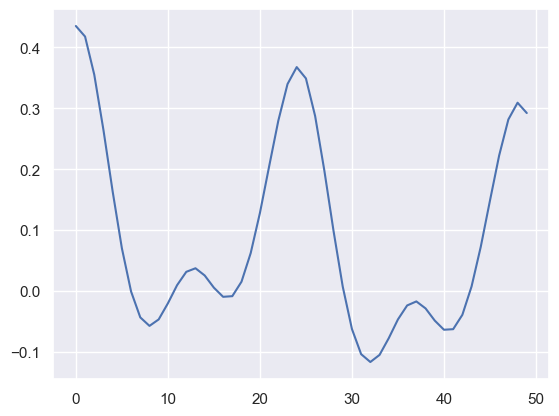

In [118]:
cross_corr = ccf(df_final['total load actual'], df_final['price actual'])
plt.plot(cross_corr[0:50])
plt.show()

In [119]:
# Find the correlations between the electricity price and the rest of the features

correlations = df_final.corr(method='pearson')
print(correlations['price actual'].sort_values(ascending=False).to_string())

price actual                                   1.000000
price day ahead                                0.732155
generation fossil hard coal                    0.465637
generation fossil gas                          0.461452
total load actual                              0.435253
generation fossil brown coal/lignite           0.363993
generation fossil oil                          0.285050
generation other renewable                     0.255551
pressure_Barcelona                             0.249177
pressure_Bilbao                                0.194063
generation waste                               0.168710
generation biomass                             0.142671
temp_min_Valencia                              0.133141
pressure_Valencia                              0.109812
temp_min_Barcelona                             0.103726
generation other                               0.099914
generation solar                               0.098529
temp_max_Madrid                                0

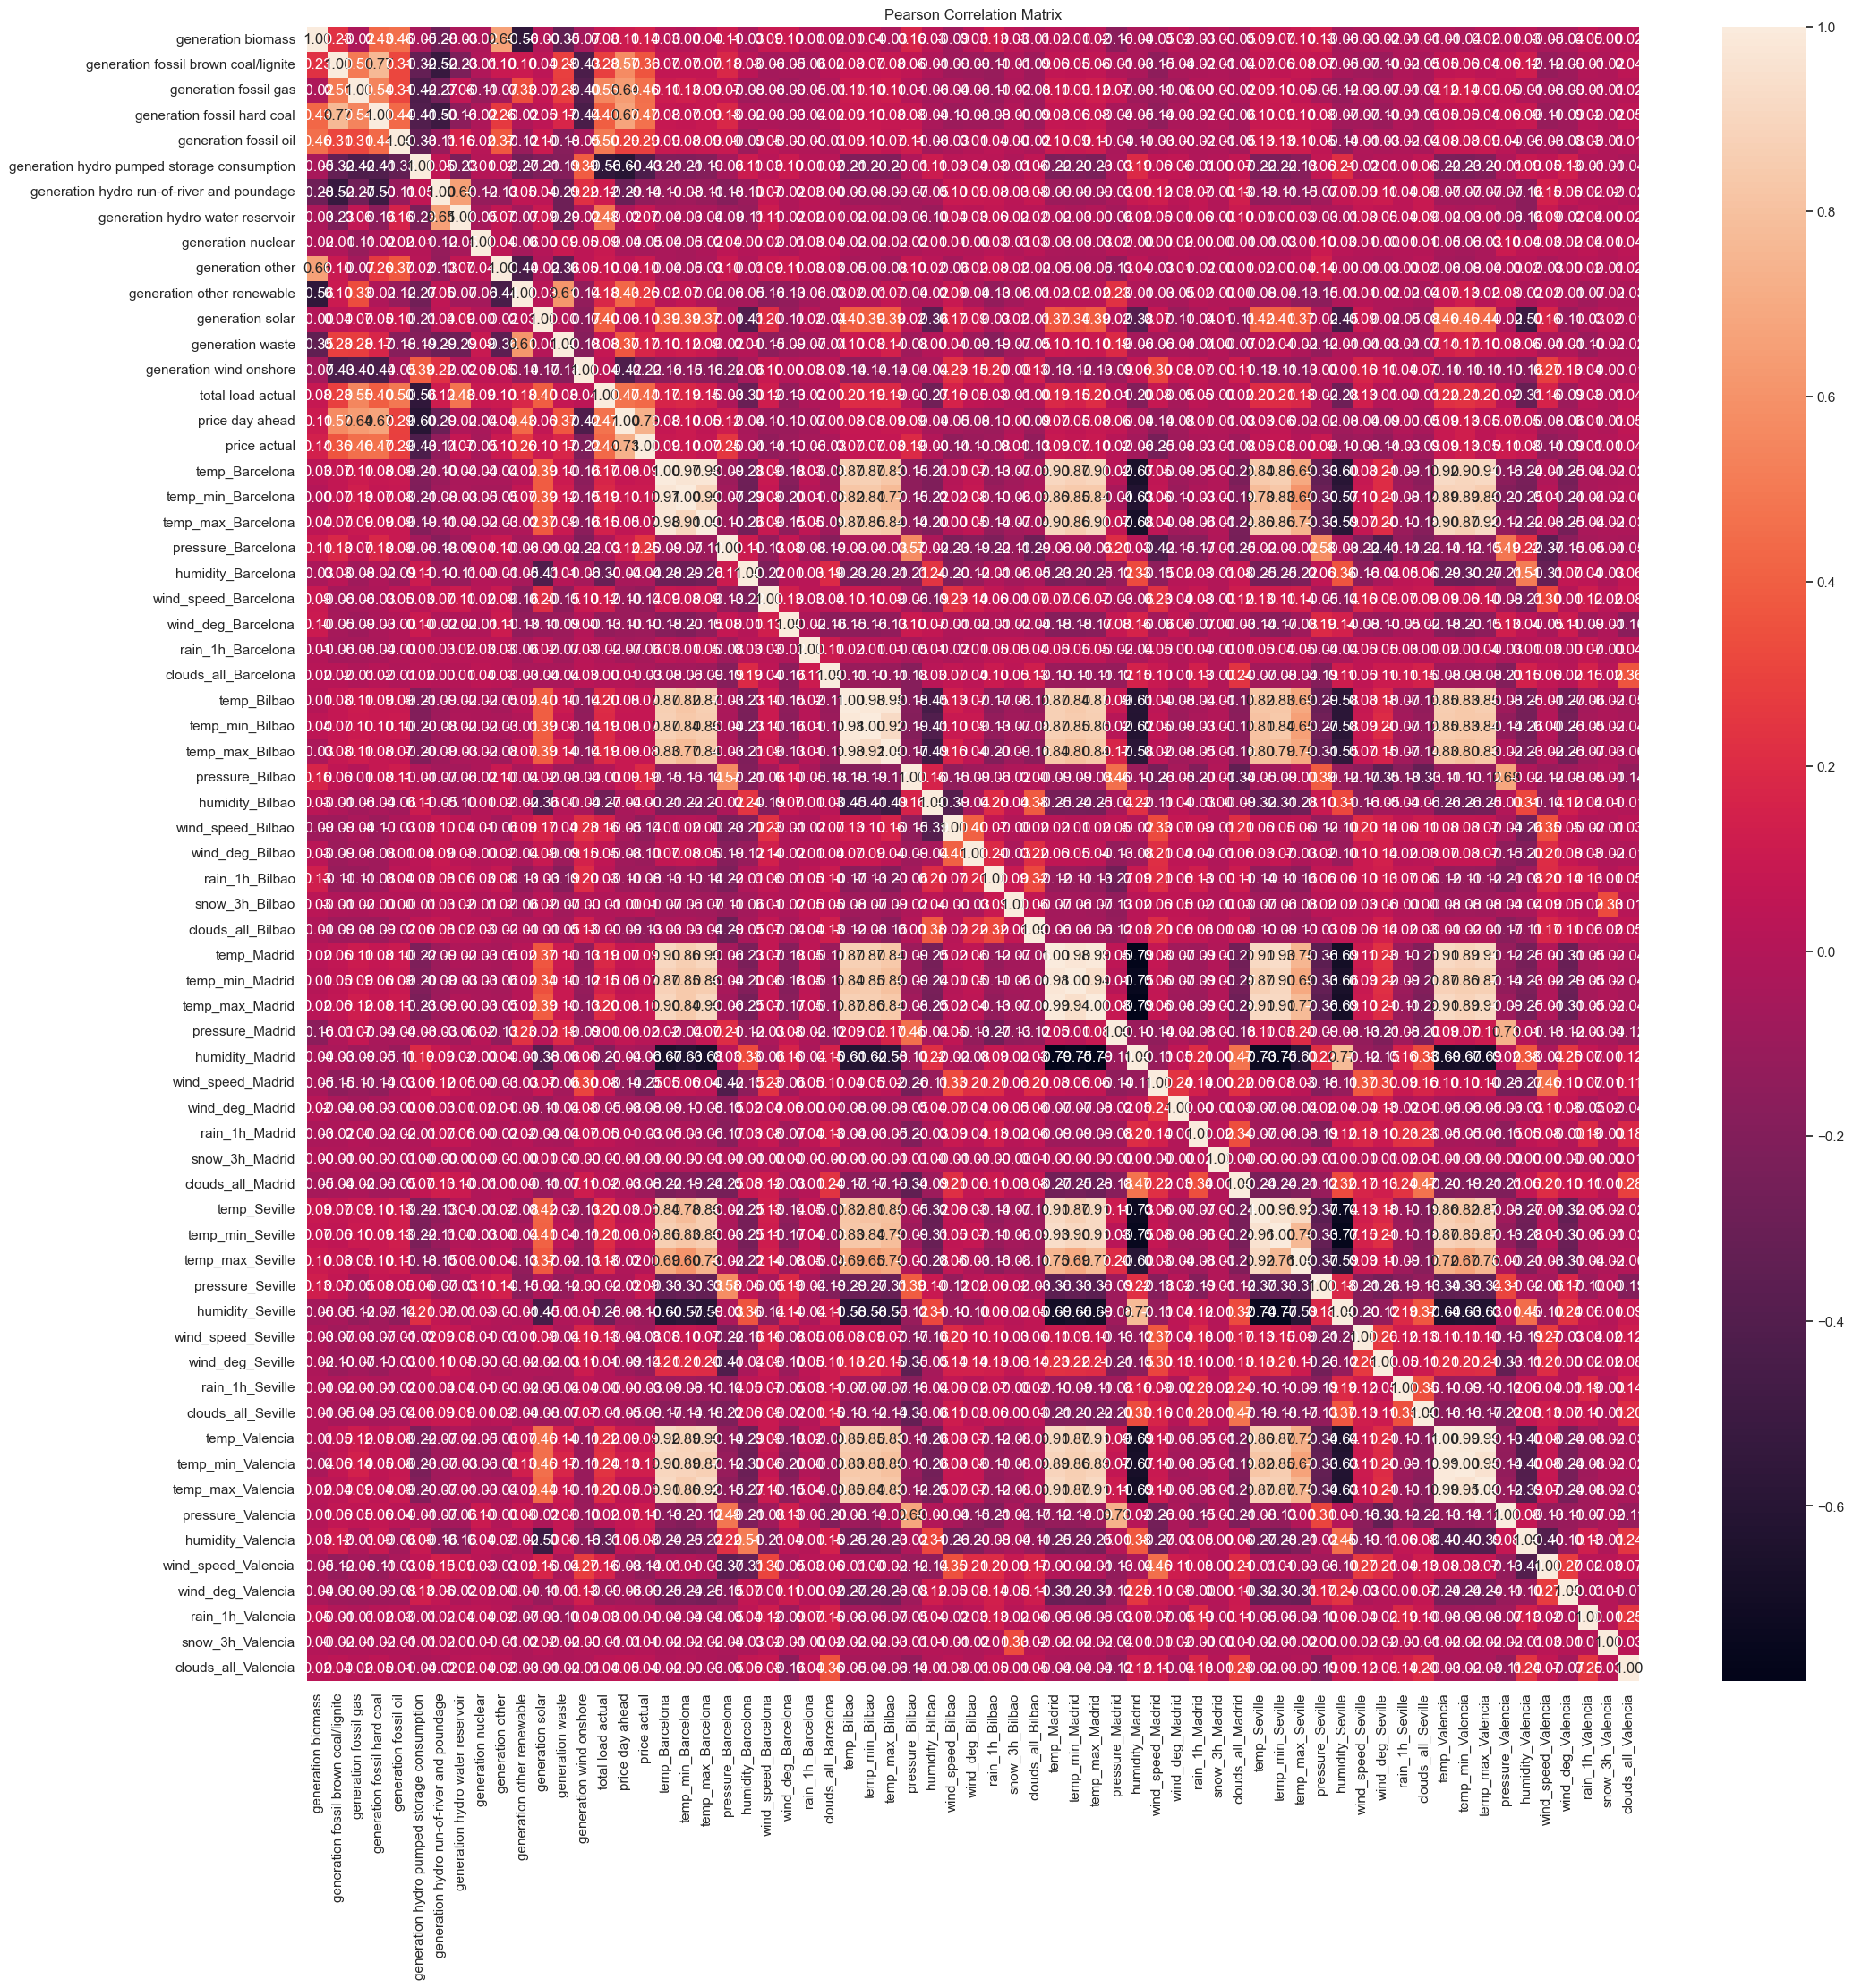

In [120]:
df_final = df_final.drop(['snow_3h_Barcelona', 'snow_3h_Seville'], axis=1)

# Plot Pearson correlation matrix

correlations = df_final.corr(method='pearson')
fig = plt.figure(figsize=(24, 24))
sns.heatmap(correlations, annot=True, fmt='.2f')
plt.title('Pearson Correlation Matrix')
plt.show()



In [121]:
highly_correlated = abs(correlations[correlations > 0.75])
print(highly_correlated[highly_correlated < 1.0].stack().to_string())

generation fossil brown coal/lignite  generation fossil hard coal             0.768831
generation fossil hard coal           generation fossil brown coal/lignite    0.768831
temp_Barcelona                        temp_min_Barcelona                      0.970264
                                      temp_max_Barcelona                      0.976904
                                      temp_Bilbao                             0.866727
                                      temp_min_Bilbao                         0.867970
                                      temp_max_Bilbao                         0.828347
                                      temp_Madrid                             0.903996
                                      temp_min_Madrid                         0.874548
                                      temp_max_Madrid                         0.899010
                                      temp_Seville                            0.841910
                                      temp_

In [122]:
# Generate 'hour', 'weekday' and 'month' features

for i in range(len(df_final)):
    position = df_final.index[i]
    hour = position.hour
    weekday = position.weekday()
    month = position.month
    df_final.loc[position, 'hour'] = hour
    df_final.loc[position, 'weekday'] = weekday
    df_final.loc[position, 'month'] = month

# Generate 'business hour' feature

for i in range(len(df_final)):
    position = df_final.index[i]
    hour = position.hour
    if ((hour > 8 and hour < 14) or (hour > 16 and hour < 21)):
        df_final.loc[position, 'business hour'] = 2
    elif (hour >= 14 and hour <= 16):
        df_final.loc[position, 'business hour'] = 1
    else:
        df_final.loc[position, 'business hour'] = 0

# Generate 'weekend' feature

for i in range(len(df_final)):
    position = df_final.index[i]
    weekday = position.weekday()
    if (weekday == 6):
        df_final.loc[position, 'weekday'] = 2
    elif (weekday == 5):
        df_final.loc[position, 'weekday'] = 1
    else:
        df_final.loc[position, 'weekday'] = 0

# Generate 'temp_range' for each city

cities = ['Barcelona', 'Bilbao', 'Madrid', 'Seville', 'Valencia']

for i in range(len(df_final)):
    position = df_final.index[i]
    for city in cities:
        temp_max = df_final.loc[position, 'temp_max_{}'.format(city)]
        temp_min = df_final.loc[position, 'temp_min_{}'.format(city)]
        df_final.loc[position, 'temp_range_{}'.format(city)] = abs(temp_max - temp_min)

In [123]:
# Calculate the weight of every city

total_pop = 6155116 + 5179243 + 1645342 + 1305342 + 987000

weight_Madrid = 6155116 / total_pop
weight_Barcelona = 5179243 / total_pop
weight_Valencia = 1645342 / total_pop
weight_Seville = 1305342 / total_pop
weight_Bilbao = 987000 / total_pop

cities_weights = {'Madrid': weight_Madrid, 
                  'Barcelona': weight_Barcelona,
                  'Valencia': weight_Valencia,
                  'Seville': weight_Seville,
                  'Bilbao': weight_Bilbao}

# Generate 'temp_weighted' feature

for i in range(len(df_final)):
    position = df_final.index[i]
    temp_weighted = 0
    for city in cities:
        temp = df_final.loc[position, 'temp_{}'.format(city)]
        temp_weighted += temp * cities_weights.get('{}'.format(city))
    df_final.loc[position, 'temp_weighted'] = temp_weighted



In [124]:
df_final['generation coal all'] = df_final['generation fossil hard coal'] + df_final['generation fossil brown coal/lignite']

In [125]:
def multivariate_data(dataset, target, start_index, end_index, history_size,
                      target_size, step, single_step=False):
    data = []
    labels = []

    start_index = start_index + history_size
    if end_index is None:
        end_index = len(dataset) - target_size
        
    for i in range(start_index, end_index):
        indices = range(i-history_size, i, step)
        data.append(dataset[indices])
        
        if single_step:
            labels.append(target[i + target_size])
        else:
            labels.append(target[i : i + target_size])

    return np.array(data), np.array(labels)

train_end_idx = 27048
cv_end_idx = 31056
test_end_idx = 35064

X = df_final[df_final.columns.drop('price actual')].values
y = df_final['price actual'].values

y = y.reshape(-1, 1)

scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

scaler_X.fit(X[:train_end_idx])
scaler_y.fit(y[:train_end_idx])



,feature_range,"(0, ...)"
,copy,True
,clip,False


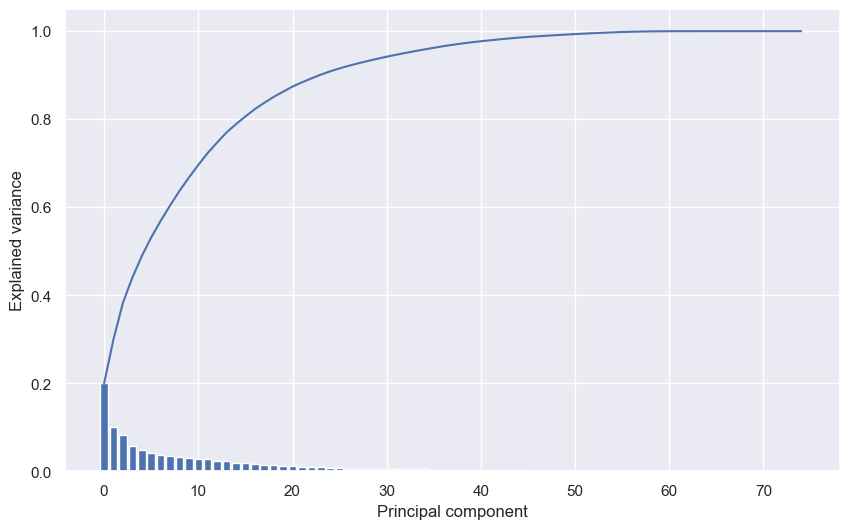

In [126]:
X_norm = scaler_X.transform(X)
y_norm = scaler_y.transform(y)

pca = PCA()
X_pca = pca.fit(X_norm[:train_end_idx])

num_components = len(pca.explained_variance_ratio_)
plt.figure(figsize=(10, 6))
plt.bar(np.arange(num_components), pca.explained_variance_ratio_)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Principal component')
plt.ylabel('Explained variance')
plt.show()



In [127]:
pca = PCA(n_components=0.80)
pca.fit(X_norm[:train_end_idx])
X_pca = pca.transform(X_norm)

X_pca.shape



(35064, 16)

In [128]:
dataset_norm = np.concatenate((X_pca, y_norm), axis=1)

past_history = 24
future_target = 0

X_train, y_train = multivariate_data(dataset_norm, dataset_norm[:, -1],
                                     0, train_end_idx, past_history, 
                                     future_target, step=1, single_step=True)

X_val, y_val = multivariate_data(dataset_norm, dataset_norm[:, -1],
                                 train_end_idx, cv_end_idx, past_history, 
                                 future_target, step=1, single_step=True)

X_test, y_test = multivariate_data(dataset_norm, dataset_norm[:, -1],
                                   cv_end_idx, test_end_idx, past_history, 
                                   future_target, step=1, single_step=True)

batch_size = 32
buffer_size = 1000

train = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train = train.cache().shuffle(buffer_size).batch(batch_size).prefetch(1)

validation = tf.data.Dataset.from_tensor_slices((X_val, y_val))
validation = validation.batch(batch_size).prefetch(1)

# Define some common parameters

input_shape = X_train.shape[-2:]
loss = tf.keras.losses.MeanSquaredError()
metric = [tf.keras.metrics.RootMeanSquaredError()]
lr_schedule = tf.keras.callbacks.LearningRateScheduler(
              lambda epoch: 1e-4 * 10**(epoch / 10))
early_stopping = tf.keras.callbacks.EarlyStopping(patience=10)

y_test = y_test.reshape(-1, 1)
y_test_inv = scaler_y.inverse_transform(y_test)



Electricity Price Forecasting

In [129]:
def plot_model_rmse_and_loss(history):
    
    # Evaluate train and validation accuracies and losses
    
    train_rmse = history.history['root_mean_squared_error']
    val_rmse = history.history['val_root_mean_squared_error']
    
    train_loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    # Visualize epochs vs. train and validation accuracies and losses
    
    plt.figure(figsize=(20, 10))
    plt.subplot(1, 2, 1)
    plt.plot(train_rmse, label='Training RMSE')
    plt.plot(val_rmse, label='Validation RMSE')
    plt.legend()
    plt.title('Epochs vs. Training and Validation RMSE')
    
    plt.subplot(1, 2, 2)
    plt.plot(train_loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.legend()
    plt.title('Epochs vs. Training and Validation Loss')
    
    plt.show()

XGBoost

In [130]:
X_train_xgb = X_train.reshape(-1, X_train.shape[1] * X_train.shape[2])
X_val_xgb = X_val.reshape(-1, X_val.shape[1] * X_val.shape[2])
X_test_xgb = X_test.reshape(-1, X_test.shape[1] * X_test.shape[2])

param = {'eta': 0.03, 'max_depth': 180, 
         'subsample': 1.0, 'colsample_bytree': 0.95, 
         'alpha': 0.1, 'lambda': 0.15, 'gamma': 0.1,
         'objective': 'reg:linear', 'eval_metric': 'rmse', 
         'silent': 1, 'min_child_weight': 0.1, 'n_jobs': -1}

dtrain = xgb.DMatrix(X_train_xgb, y_train)
dval = xgb.DMatrix(X_val_xgb, y_val)
dtest = xgb.DMatrix(X_test_xgb, y_test)
eval_list = [(dtrain, 'train'), (dval, 'eval')]

xgb_model = xgb.train(param, dtrain, 180, eval_list, early_stopping_rounds=3)



[0]	train-rmse:0.12946	eval-rmse:0.10910
[1]	train-rmse:0.12582	eval-rmse:0.10602
[2]	train-rmse:0.12229	eval-rmse:0.10311
[3]	train-rmse:0.11888	eval-rmse:0.10025
[4]	train-rmse:0.11558	eval-rmse:0.09747
[5]	train-rmse:0.11238	eval-rmse:0.09479
[6]	train-rmse:0.10928	eval-rmse:0.09219
[7]	train-rmse:0.10628	eval-rmse:0.08966
[8]	train-rmse:0.10337	eval-rmse:0.08725
[9]	train-rmse:0.10055	eval-rmse:0.08489
[10]	train-rmse:0.09783	eval-rmse:0.08262
[11]	train-rmse:0.09519	eval-rmse:0.08042
[12]	train-rmse:0.09279	eval-rmse:0.07854
[13]	train-rmse:0.09032	eval-rmse:0.07649
[14]	train-rmse:0.08793	eval-rmse:0.07453
[15]	train-rmse:0.08577	eval-rmse:0.07280
[16]	train-rmse:0.08352	eval-rmse:0.07093
[17]	train-rmse:0.08135	eval-rmse:0.06913
[18]	train-rmse:0.07925	eval-rmse:0.06736
[19]	train-rmse:0.07722	eval-rmse:0.06569
[20]	train-rmse:0.07526	eval-rmse:0.06408
[21]	train-rmse:0.07336	eval-rmse:0.06252
[22]	train-rmse:0.07152	eval-rmse:0.06102
[23]	train-rmse:0.06975	eval-rmse:0.05951
[2

In [131]:
forecast = xgb_model.predict(dtest)
xgb_forecast = forecast.reshape(-1, 1)

xgb_forecast_inv = scaler_y.inverse_transform(xgb_forecast)

rmse_xgb = sqrt(mean_squared_error(y_test_inv, xgb_forecast_inv))
print('RMSE of hour-ahead electricity price XGBoost forecast: {}'
      .format(round(rmse_xgb, 3)))

RMSE of hour-ahead electricity price XGBoost forecast: 2.227


LSTM

In [132]:
tf.keras.backend.clear_session()

multivariate_lstm = tf.keras.models.Sequential([
    LSTM(100, input_shape=input_shape, 
         return_sequences=True),
    Flatten(),
    Dense(200, activation='relu'),
    Dropout(0.1),
    Dense(1)
])

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "multivariate_lstm.keras",
    monitor="val_loss",
    save_best_only=True
)

optimizer = tf.keras.optimizers.Adam(learning_rate=6e-3, amsgrad=True)


multivariate_lstm.compile(loss=loss,
                          optimizer=optimizer,
                          metrics=metric)

history = multivariate_lstm.fit(train, epochs=120,
                                validation_data=validation,
                                callbacks=[early_stopping, 
                                           model_checkpoint])



Epoch 1/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0533 - root_mean_squared_error: 0.2309 - val_loss: 0.0050 - val_root_mean_squared_error: 0.0709
Epoch 2/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0037 - root_mean_squared_error: 0.0605 - val_loss: 0.0035 - val_root_mean_squared_error: 0.0594
Epoch 3/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0029 - root_mean_squared_error: 0.0536 - val_loss: 0.0037 - val_root_mean_squared_error: 0.0608
Epoch 4/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0023 - root_mean_squared_error: 0.0484 - val_loss: 0.0024 - val_root_mean_squared_error: 0.0489
Epoch 5/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0021 - root_mean_squared_error: 0.0455 - val_loss: 0.0026 - val_root_mean_squared_error: 0.0510
Epoch 6/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0017 - root_mean_squared_error: 0.0418 - val_loss: 0.0023 - val_root_mean_squared_error: 0.0478
Epoch 7/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 5s 6m

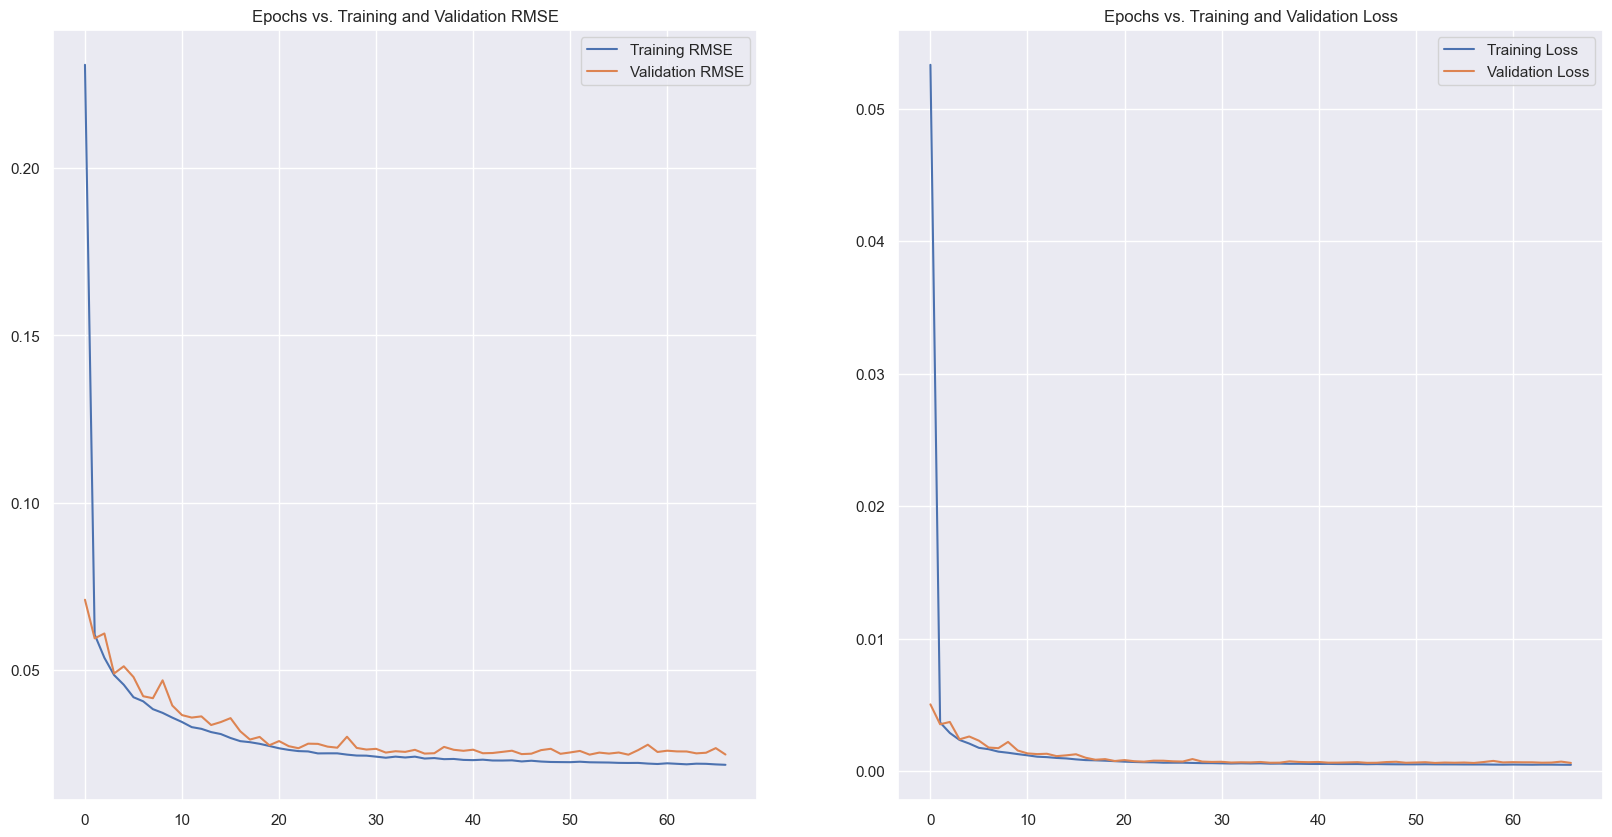

In [133]:
plot_model_rmse_and_loss(history)

In [134]:
multivariate_lstm = tf.keras.models.load_model('multivariate_lstm.h5')

forecast = multivariate_lstm.predict(X_test)
lstm_forecast = scaler_y.inverse_transform(forecast)

rmse_lstm = sqrt(mean_squared_error(y_test_inv,
                                    lstm_forecast))
print('RMSE of hour-ahead electricity price LSTM forecast: {}'
      .format(round(rmse_lstm, 3)))

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'multivariate_lstm.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

Stacked LSTM

In [ ]:
tf.keras.backend.clear_session()

multivariate_stacked_lstm = tf.keras.models.Sequential([
    LSTM(250, input_shape=input_shape, 
         return_sequences=True),
    LSTM(150, return_sequences=True),
    Flatten(),
    Dense(150, activation='relu'),
    Dropout(0.1),
    Dense(1)
])

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
                   'multivariate_stacked_lstm.h5', save_best_only=True)
optimizer = tf.keras.optimizers.Adam(learning_rate=3e-3, amsgrad=True)


multivariate_stacked_lstm.compile(loss=loss,
                                  optimizer=optimizer,
                                  metrics=metric)

history = multivariate_stacked_lstm.fit(train, epochs=120,
                                validation_data=validation,
                                callbacks=[early_stopping, 
                                           model_checkpoint])



Epoch 1/120
843/845 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0913 - root_mean_squared_error: 0.1810

845/845 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 0.0206 - root_mean_squared_error: 0.1342 - val_loss: 0.0072 - val_root_mean_squared_error: 0.0851
Epoch 2/120
843/845 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0049 - root_mean_squared_error: 0.0699

845/845 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - loss: 0.0038 - root_mean_squared_error: 0.0620 - val_loss: 0.0046 - val_root_mean_squared_error: 0.0677
Epoch 3/120
844/845 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0036 - root_mean_squared_error: 0.0593

845/845 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - loss: 0.0028 - root_mean_squared_error: 0.0534 - val_loss: 0.0031 - val_root_mean_squared_error: 0.0553
Epoch 4/120
844/845 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0028 - root_mean_squared_error: 0.0529

845/845 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 0.0023 - root_mean_squared_error: 0.0478 - val_loss: 0.0028 - val_root_mean_squared_error: 0.0530
Epoch 5/120
844/845 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0026 - root_mean_squared_error: 0.0504

845/845 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - loss: 0.0021 - root_mean_squared_error: 0.0455 - val_loss: 0.0023 - val_root_mean_squared_error: 0.0477
Epoch 6/120
844/845 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0022 - root_mean_squared_error: 0.0465

845/845 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 0.0018 - root_mean_squared_error: 0.0422 - val_loss: 0.0021 - val_root_mean_squared_error: 0.0455
Epoch 7/120
844/845 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0018 - root_mean_squared_error: 0.0427

845/845 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - loss: 0.0015 - root_mean_squared_error: 0.0392 - val_loss: 0.0015 - val_root_mean_squared_error: 0.0387
Epoch 8/120
844/845 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0017 - root_mean_squared_error: 0.0409

845/845 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - loss: 0.0014 - root_mean_squared_error: 0.0372 - val_loss: 0.0013 - val_root_mean_squared_error: 0.0362
Epoch 9/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - loss: 0.0012 - root_mean_squared_error: 0.0343 - val_loss: 0.0018 - val_root_mean_squared_error: 0.0424
Epoch 10/120
842/845 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0013 - root_mean_squared_error: 0.0363

845/845 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 0.0011 - root_mean_squared_error: 0.0330 - val_loss: 0.0012 - val_root_mean_squared_error: 0.0340


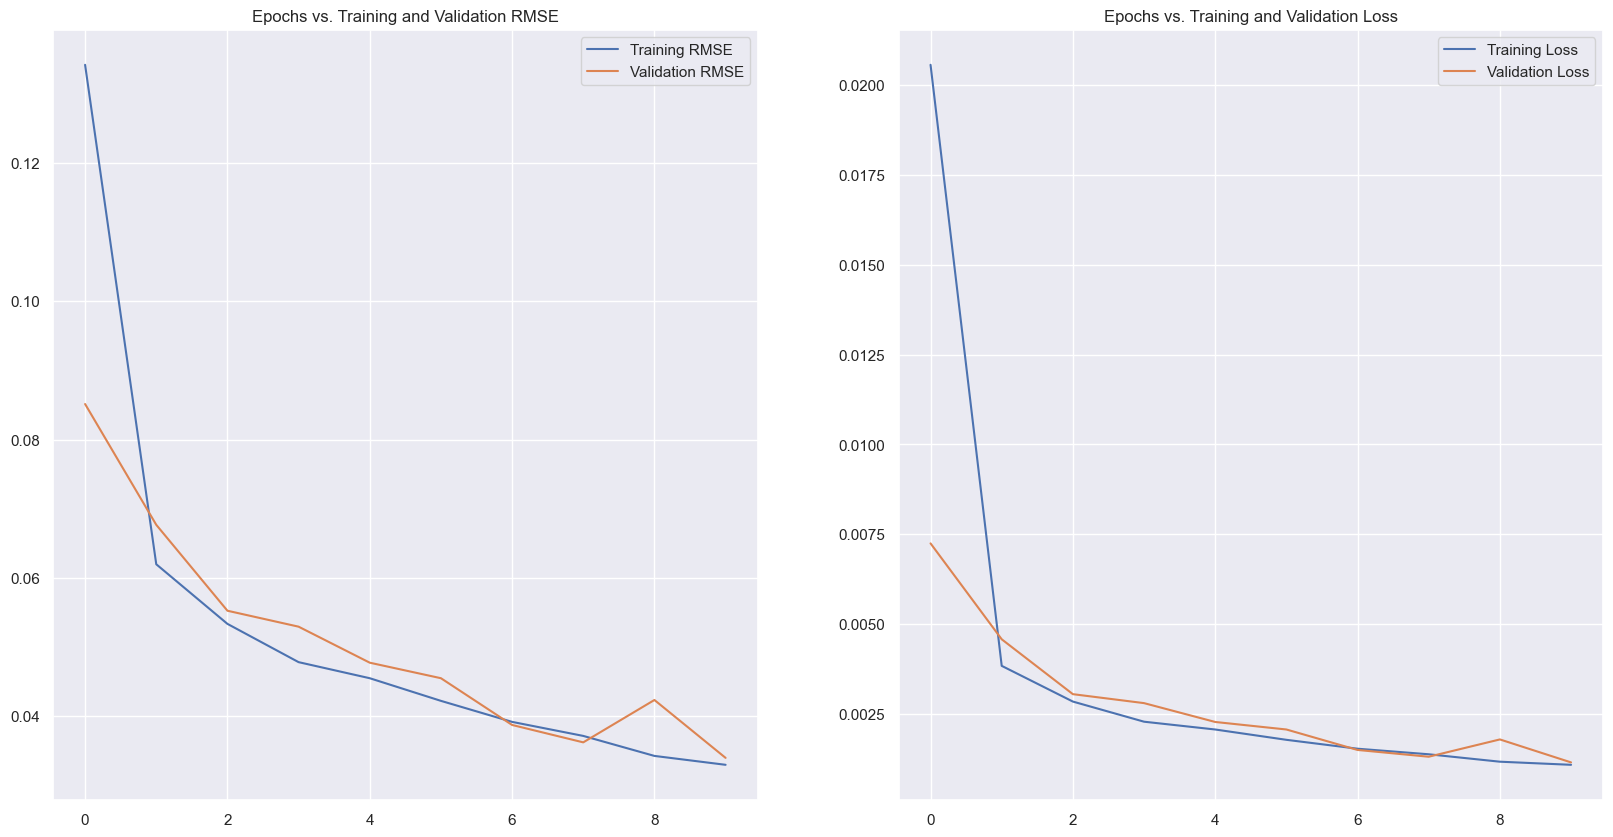

In [ ]:
plot_model_rmse_and_loss(history)

In [ ]:
multivariate_stacked_lstm = tf.keras.models.load_model('multivariate_stacked_lstm.h5')

forecast = multivariate_stacked_lstm.predict(X_test)
multivariate_stacked_lstm_forecast = scaler_y.inverse_transform(forecast)

rmse_mult_stacked_lstm = sqrt(mean_squared_error(y_test_inv, 
                                                 multivariate_stacked_lstm_forecast))
print('RMSE of hour-ahead electricity price multivariate Stacked LSTM forecast: {}'
      .format(round(rmse_mult_stacked_lstm, 3)))

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
RMSE of hour-ahead electricity price multivariate Stacked LSTM forecast: 4.11


CNN

In [ ]:
tf.keras.backend.clear_session()

multivariate_cnn = tf.keras.models.Sequential([
    Conv1D(filters=48, kernel_size=2,
           strides=1, padding='causal',
           activation='relu', 
           input_shape=input_shape),
    Flatten(),
    Dense(48, activation='relu'),
    Dense(1)
])

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
                   'multivariate_cnn.h5', save_best_only=True)
optimizer = tf.keras.optimizers.Adam(learning_rate=6e-3, amsgrad=True)


multivariate_cnn.compile(loss=loss,
                          optimizer=optimizer,
                          metrics=metric)

history = multivariate_cnn.fit(train, epochs=120,
                               validation_data=validation,
                               callbacks=[early_stopping, 
                                          model_checkpoint])



Epoch 1/120
834/845 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1300 - root_mean_squared_error: 0.2230

845/845 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0286 - root_mean_squared_error: 0.1584 - val_loss: 0.0047 - val_root_mean_squared_error: 0.0688
Epoch 2/120
835/845 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0032 - root_mean_squared_error: 0.0555

845/845 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0023 - root_mean_squared_error: 0.0476 - val_loss: 0.0037 - val_root_mean_squared_error: 0.0607
Epoch 3/120
836/845 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0022 - root_mean_squared_error: 0.0468

845/845 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0017 - root_mean_squared_error: 0.0408 - val_loss: 0.0029 - val_root_mean_squared_error: 0.0536
Epoch 4/120
839/845 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0017 - root_mean_squared_error: 0.0412

845/845 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0014 - root_mean_squared_error: 0.0368 - val_loss: 0.0019 - val_root_mean_squared_error: 0.0441
Epoch 5/120
834/845 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0014 - root_mean_squared_error: 0.0375

845/845 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0012 - root_mean_squared_error: 0.0342 - val_loss: 0.0015 - val_root_mean_squared_error: 0.0386
Epoch 6/120
839/845 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0013 - root_mean_squared_error: 0.0356

845/845 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0010 - root_mean_squared_error: 0.0321 - val_loss: 0.0015 - val_root_mean_squared_error: 0.0385
Epoch 7/120
844/845 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0012 - root_mean_squared_error: 0.0344

845/845 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 9.6711e-04 - root_mean_squared_error: 0.0311 - val_loss: 0.0012 - val_root_mean_squared_error: 0.0346
Epoch 8/120
838/845 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0011 - root_mean_squared_error: 0.0327

845/845 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 8.8449e-04 - root_mean_squared_error: 0.0297 - val_loss: 0.0012 - val_root_mean_squared_error: 0.0344
Epoch 9/120
831/845 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0011 - root_mean_squared_error: 0.0324

845/845 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 8.6322e-04 - root_mean_squared_error: 0.0294 - val_loss: 0.0011 - val_root_mean_squared_error: 0.0333
Epoch 10/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 7.9794e-04 - root_mean_squared_error: 0.0282 - val_loss: 0.0013 - val_root_mean_squared_error: 0.0358


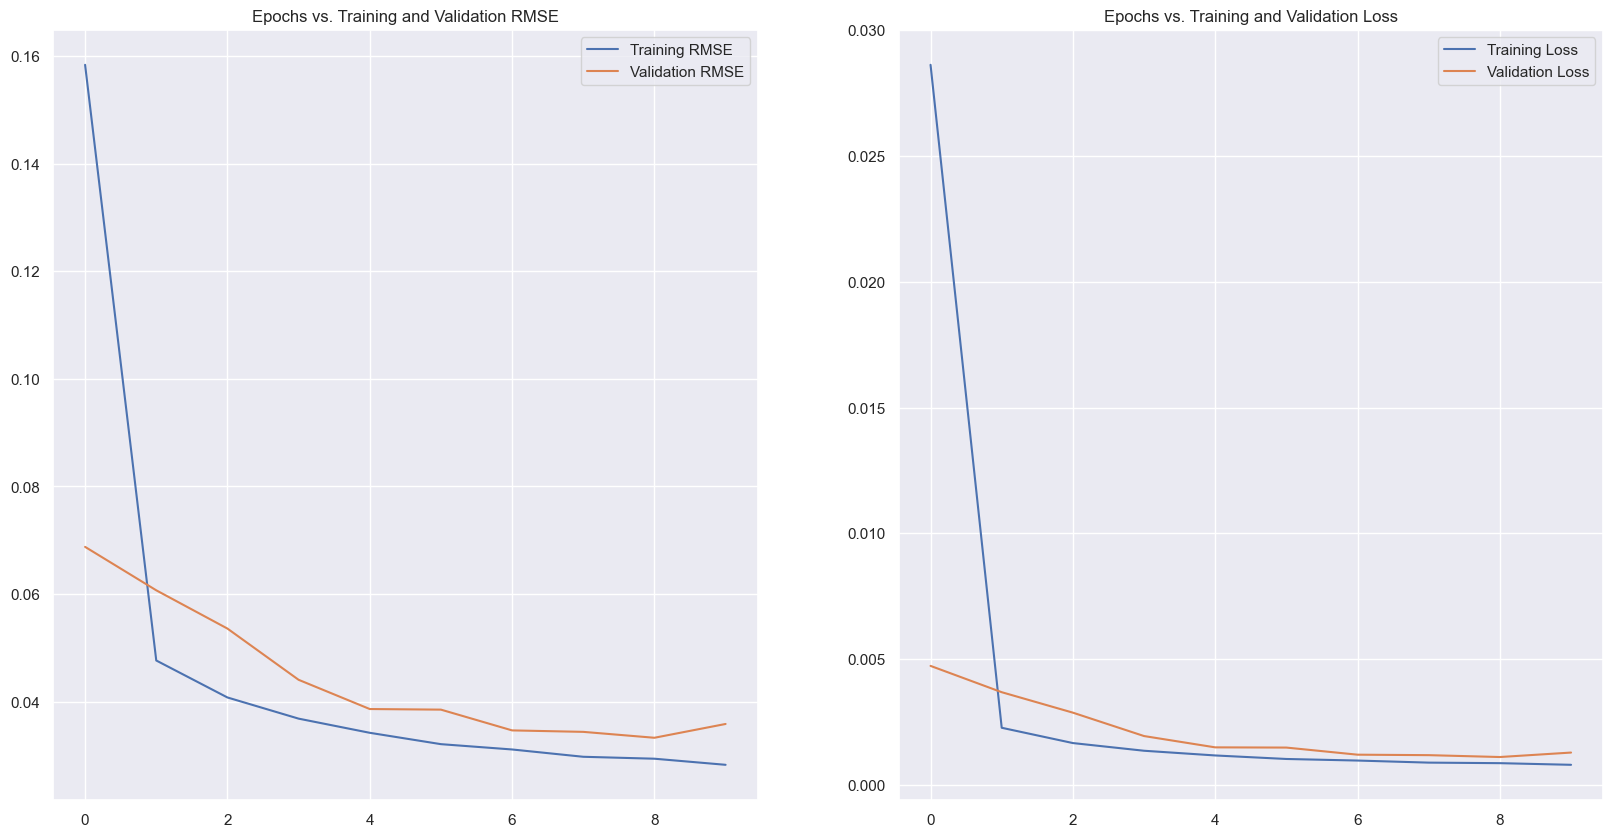

In [ ]:
plot_model_rmse_and_loss(history)

In [ ]:
multivariate_cnn = tf.keras.models.load_model('multivariate_cnn.h5')

forecast = multivariate_cnn.predict(X_test)
multivariate_cnn_forecast = scaler_y.inverse_transform(forecast)

rmse_mult_cnn = sqrt(mean_squared_error(y_test_inv,
                                        multivariate_cnn_forecast))
print('RMSE of hour-ahead electricity price multivariate CNN forecast: {}'
      .format(round(rmse_mult_cnn, 3)))

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 785us/step
RMSE of hour-ahead electricity price multivariate CNN forecast: 2.989


CNN-LSTM

In [ ]:
tf.keras.backend.clear_session()

multivariate_cnn_lstm = tf.keras.models.Sequential([
    Conv1D(filters=100, kernel_size=2,
           strides=1, padding='causal',
           activation='relu', 
           input_shape=input_shape),
    LSTM(100, return_sequences=True),
    Flatten(),
    Dense(50, activation='relu'),
    Dense(1)
])

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
                   'multivariate_cnn_lstm.h5', save_best_only=True)
optimizer = tf.keras.optimizers.Adam(learning_rate=4e-3, amsgrad=True)


multivariate_cnn_lstm.compile(loss=loss,
                          optimizer=optimizer,
                          metrics=metric)

history = multivariate_cnn_lstm.fit(train, epochs=120,
                                    validation_data=validation,
                                    callbacks=[early_stopping, 
                                               model_checkpoint])



Epoch 1/120
842/845 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0557 - root_mean_squared_error: 0.1436

845/845 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0125 - root_mean_squared_error: 0.1053 - val_loss: 0.0052 - val_root_mean_squared_error: 0.0719
Epoch 2/120
841/845 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0026 - root_mean_squared_error: 0.0507

845/845 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0019 - root_mean_squared_error: 0.0439 - val_loss: 0.0028 - val_root_mean_squared_error: 0.0532
Epoch 3/120
844/845 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0019 - root_mean_squared_error: 0.0433

845/845 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0014 - root_mean_squared_error: 0.0376 - val_loss: 0.0018 - val_root_mean_squared_error: 0.0426
Epoch 4/120
838/845 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0015 - root_mean_squared_error: 0.0381

845/845 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0011 - root_mean_squared_error: 0.0335 - val_loss: 0.0016 - val_root_mean_squared_error: 0.0397
Epoch 5/120
840/845 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0012 - root_mean_squared_error: 0.0337

845/845 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 9.2064e-04 - root_mean_squared_error: 0.0303 - val_loss: 0.0015 - val_root_mean_squared_error: 0.0386
Epoch 6/120
839/845 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.8008e-04 - root_mean_squared_error: 0.0311

845/845 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 7.9104e-04 - root_mean_squared_error: 0.0281 - val_loss: 9.4486e-04 - val_root_mean_squared_error: 0.0307
Epoch 7/120
841/845 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.0527e-04 - root_mean_squared_error: 0.0299

845/845 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 7.1791e-04 - root_mean_squared_error: 0.0268 - val_loss: 9.2804e-04 - val_root_mean_squared_error: 0.0305
Epoch 8/120
844/845 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.7426e-04 - root_mean_squared_error: 0.0294

845/845 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 6.8557e-04 - root_mean_squared_error: 0.0262 - val_loss: 7.9890e-04 - val_root_mean_squared_error: 0.0283
Epoch 9/120
836/845 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.3568e-04 - root_mean_squared_error: 0.0270

845/845 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 6.0735e-04 - root_mean_squared_error: 0.0246 - val_loss: 7.5584e-04 - val_root_mean_squared_error: 0.0275
Epoch 10/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 6.1698e-04 - root_mean_squared_error: 0.0248 - val_loss: 8.2533e-04 - val_root_mean_squared_error: 0.0287


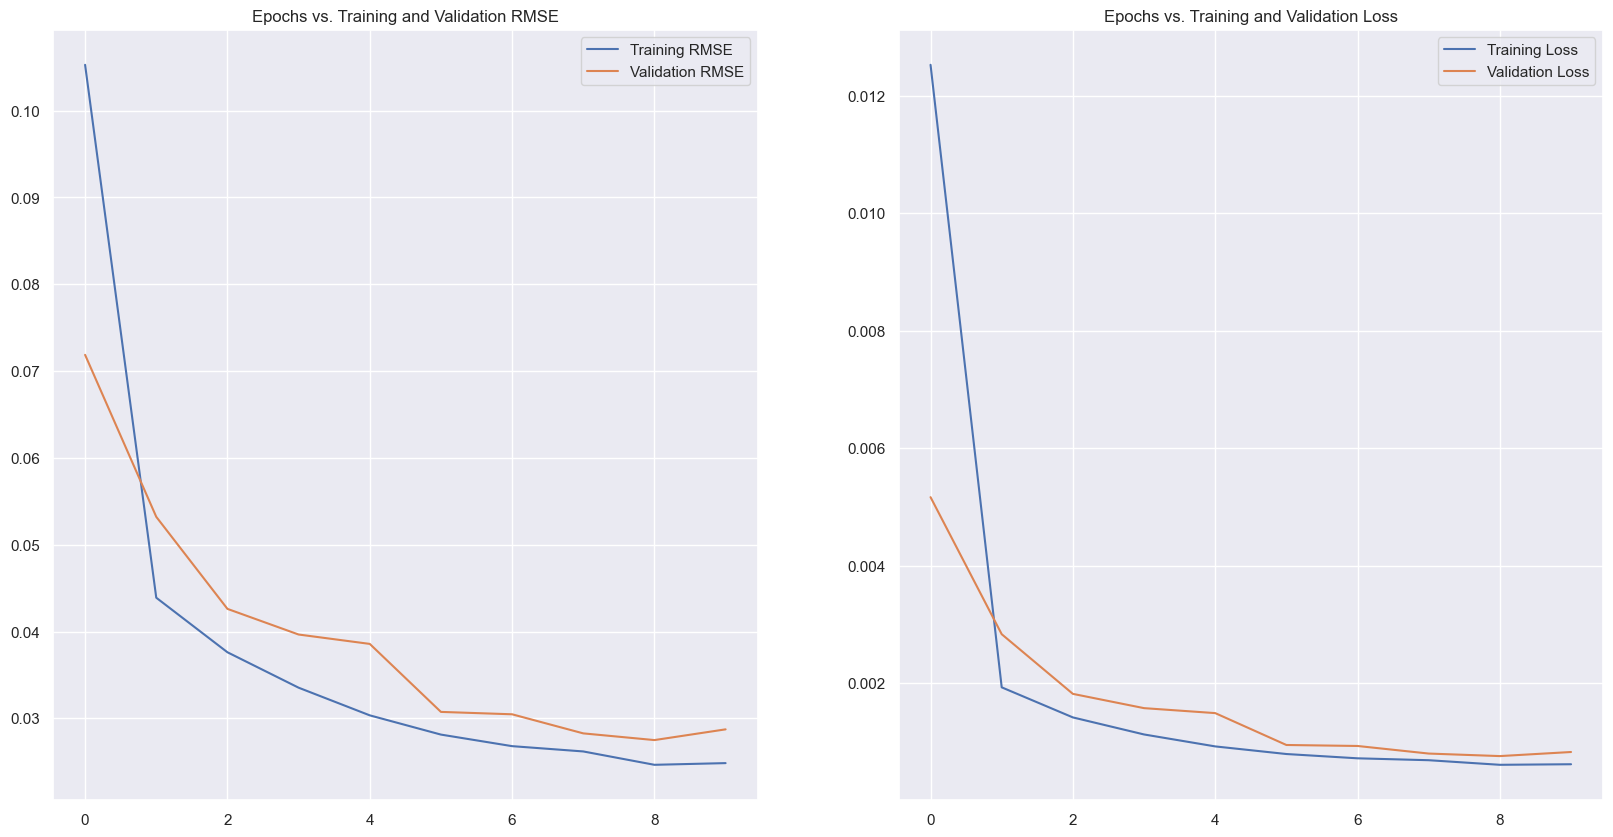

In [ ]:


plot_model_rmse_and_loss(history)



In [ ]:
multivariate_cnn_lstm = tf.keras.models.load_model('multivariate_cnn_lstm.h5')

forecast = multivariate_cnn_lstm.predict(X_test)
multivariate_cnn_lstm_forecast = scaler_y.inverse_transform(forecast)

rmse_mult_cnn_lstm = sqrt(mean_squared_error(y_test_inv, 
                                             multivariate_cnn_lstm_forecast))
print('RMSE of hour-ahead electricity price multivariate CNN-`LSTM forecast: {}'
      .format(round(rmse_mult_cnn_lstm, 3)))

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
RMSE of hour-ahead electricity price multivariate CNN-`LSTM forecast: 2.684


In [ ]:
X_test.shape

(3984, 24, 17)

Time Distributed MLP

In [ ]:
tf.keras.backend.clear_session()

multivariate_mlp = tf.keras.models.Sequential([
    TimeDistributed(Dense(200, activation='relu'),
                    input_shape=input_shape),
    TimeDistributed(Dense(150, activation='relu')),
    TimeDistributed(Dense(100, activation='relu')),
    TimeDistributed(Dense(50, activation='relu')),
    Flatten(),
    Dense(150, activation='relu'),
    Dropout(0.1),
    Dense(1)
])

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
                   'multivariate_mlp.h5', save_best_only=True)
optimizer = tf.keras.optimizers.Adam(learning_rate=2e-3, amsgrad=True)


multivariate_mlp.compile(loss=loss,
                          optimizer=optimizer,
                          metrics=metric)

history = multivariate_mlp.fit(train, epochs=120,
                               validation_data=validation,
                               callbacks=[early_stopping, 
                                          model_checkpoint])



Epoch 1/120
833/845 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0174 - root_mean_squared_error: 0.0883

845/845 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0058 - root_mean_squared_error: 0.0719 - val_loss: 0.0043 - val_root_mean_squared_error: 0.0659
Epoch 2/120
838/845 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0026 - root_mean_squared_error: 0.0504

845/845 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0019 - root_mean_squared_error: 0.0436 - val_loss: 0.0013 - val_root_mean_squared_error: 0.0363
Epoch 3/120
839/845 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0016 - root_mean_squared_error: 0.0393

845/845 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0013 - root_mean_squared_error: 0.0361 - val_loss: 0.0010 - val_root_mean_squared_error: 0.0323
Epoch 4/120
842/845 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0013 - root_mean_squared_error: 0.0355

845/845 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0011 - root_mean_squared_error: 0.0327 - val_loss: 8.8175e-04 - val_root_mean_squared_error: 0.0297
Epoch 5/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 9.5415e-04 - root_mean_squared_error: 0.0309 - val_loss: 9.5815e-04 - val_root_mean_squared_error: 0.0310
Epoch 6/120
830/845 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0011 - root_mean_squared_error: 0.0325

845/845 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 8.8235e-04 - root_mean_squared_error: 0.0297 - val_loss: 7.9250e-04 - val_root_mean_squared_error: 0.0282
Epoch 7/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 7.6035e-04 - root_mean_squared_error: 0.0276 - val_loss: 9.9528e-04 - val_root_mean_squared_error: 0.0315
Epoch 8/120
831/845 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.9377e-04 - root_mean_squared_error: 0.0298

845/845 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 7.2705e-04 - root_mean_squared_error: 0.0270 - val_loss: 7.8458e-04 - val_root_mean_squared_error: 0.0280
Epoch 9/120
844/845 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.9949e-04 - root_mean_squared_error: 0.0281

845/845 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 6.6460e-04 - root_mean_squared_error: 0.0258 - val_loss: 7.1120e-04 - val_root_mean_squared_error: 0.0267
Epoch 10/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 6.2973e-04 - root_mean_squared_error: 0.0251 - val_loss: 7.2864e-04 - val_root_mean_squared_error: 0.0270


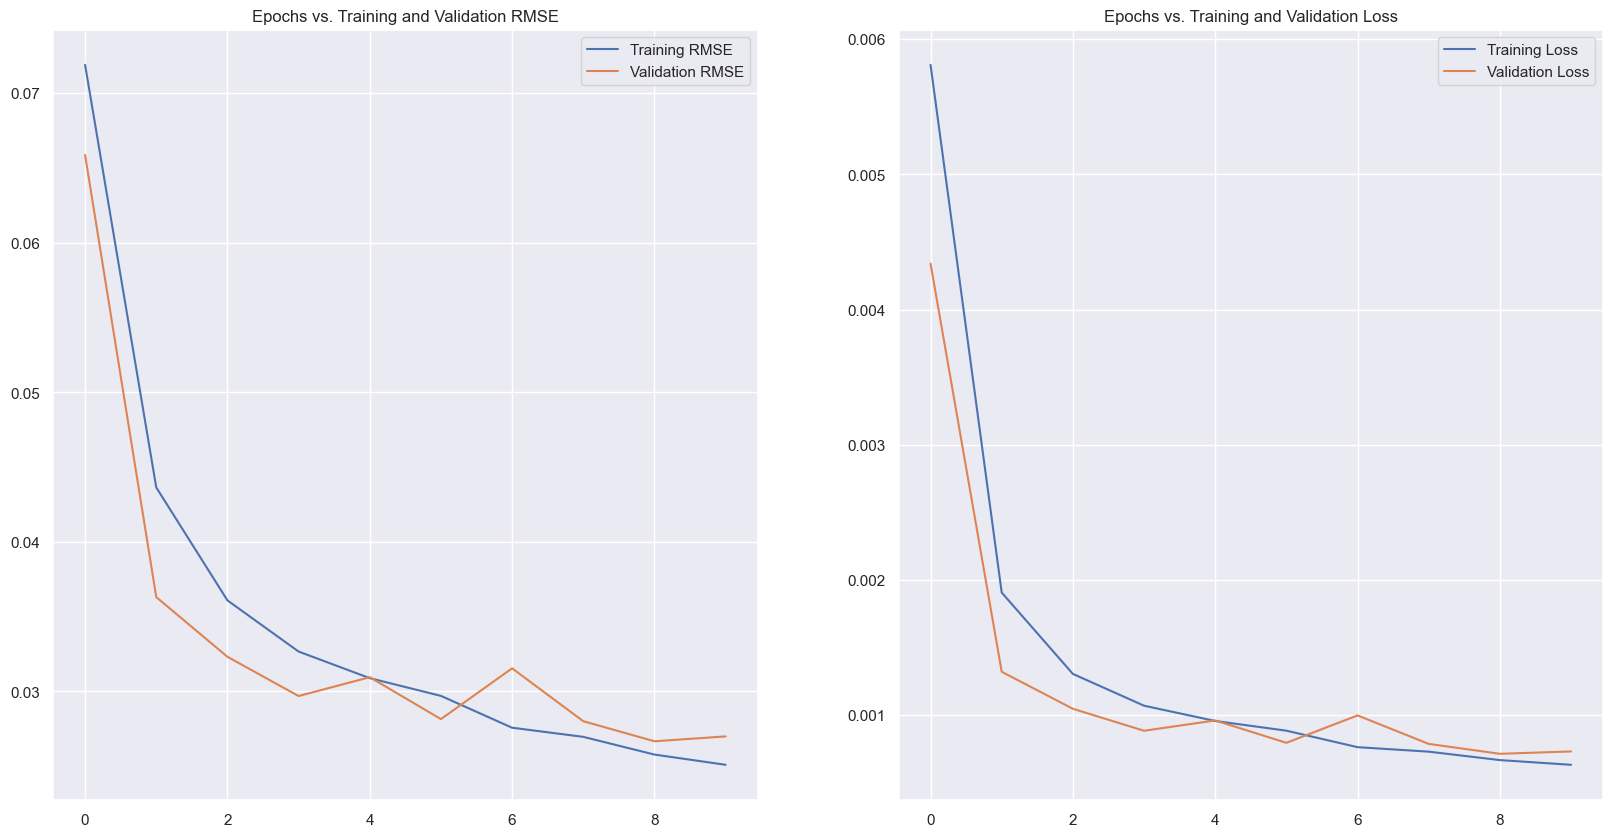

In [ ]:
plot_model_rmse_and_loss(history)

In [ ]:
multivariate_mlp = tf.keras.models.load_model('multivariate_mlp.h5')

forecast = multivariate_mlp.predict(X_test)
multivariate_mlp_forecast = scaler_y.inverse_transform(forecast)

rmse_mult_mlp = sqrt(mean_squared_error(y_test_inv,
                                        multivariate_mlp_forecast))
print('RMSE of hour-ahead electricity price multivariate MLP forecast: {}'
      .format(round(rmse_mult_mlp, 3)))

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
RMSE of hour-ahead electricity price multivariate MLP forecast: 2.484


Encoder-Decoder

In [ ]:
tf.keras.backend.clear_session()

encoder_decoder = tf.keras.models.Sequential([
    LSTM(50, activation='relu', input_shape=input_shape),
    RepeatVector(past_history),
    LSTM(50, activation='relu', return_sequences=True),
    TimeDistributed(Dense(50, activation='relu')),
    Flatten(),
    Dense(25, activation='relu'),
    Dense(1)
])



model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
                   'encoder_decoder.h5', save_best_only=True)

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3, amsgrad=True)

encoder_decoder.compile(loss=loss,
                    optimizer=optimizer,
                    metrics=metric)

history = encoder_decoder.fit(train, epochs=50,
                              validation_data=validation,
                              callbacks=[early_stopping, 
                                         model_checkpoint])



Epoch 1/50
841/845 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0192 - root_mean_squared_error: 0.0907

845/845 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0056 - root_mean_squared_error: 0.0708 - val_loss: 0.0024 - val_root_mean_squared_error: 0.0488
Epoch 2/50
841/845 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0021 - root_mean_squared_error: 0.0454

845/845 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0014 - root_mean_squared_error: 0.0380 - val_loss: 0.0017 - val_root_mean_squared_error: 0.0417
Epoch 3/50
841/845 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0015 - root_mean_squared_error: 0.0385

845/845 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0011 - root_mean_squared_error: 0.0331 - val_loss: 0.0015 - val_root_mean_squared_error: 0.0384
Epoch 4/50
841/845 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0012 - root_mean_squared_error: 0.0340

845/845 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 9.0590e-04 - root_mean_squared_error: 0.0301 - val_loss: 0.0011 - val_root_mean_squared_error: 0.0335
Epoch 5/50
845/845 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 7.8973e-04 - root_mean_squared_error: 0.0281 - val_loss: 0.0012 - val_root_mean_squared_error: 0.0344
Epoch 6/50
841/845 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.6385e-04 - root_mean_squared_error: 0.0293

845/845 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 7.0613e-04 - root_mean_squared_error: 0.0266 - val_loss: 6.7934e-04 - val_root_mean_squared_error: 0.0261
Epoch 7/50
845/845 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 6.8797e-04 - root_mean_squared_error: 0.0262 - val_loss: 6.8947e-04 - val_root_mean_squared_error: 0.0263
Epoch 8/50
840/845 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.7870e-04 - root_mean_squared_error: 0.0278

845/845 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 6.3520e-04 - root_mean_squared_error: 0.0252 - val_loss: 6.6649e-04 - val_root_mean_squared_error: 0.0258
Epoch 9/50
840/845 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.3687e-04 - root_mean_squared_error: 0.0270

845/845 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 6.0687e-04 - root_mean_squared_error: 0.0246 - val_loss: 6.3805e-04 - val_root_mean_squared_error: 0.0253
Epoch 10/50
845/845 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5.9367e-04 - root_mean_squared_error: 0.0244 - val_loss: 7.2192e-04 - val_root_mean_squared_error: 0.0269


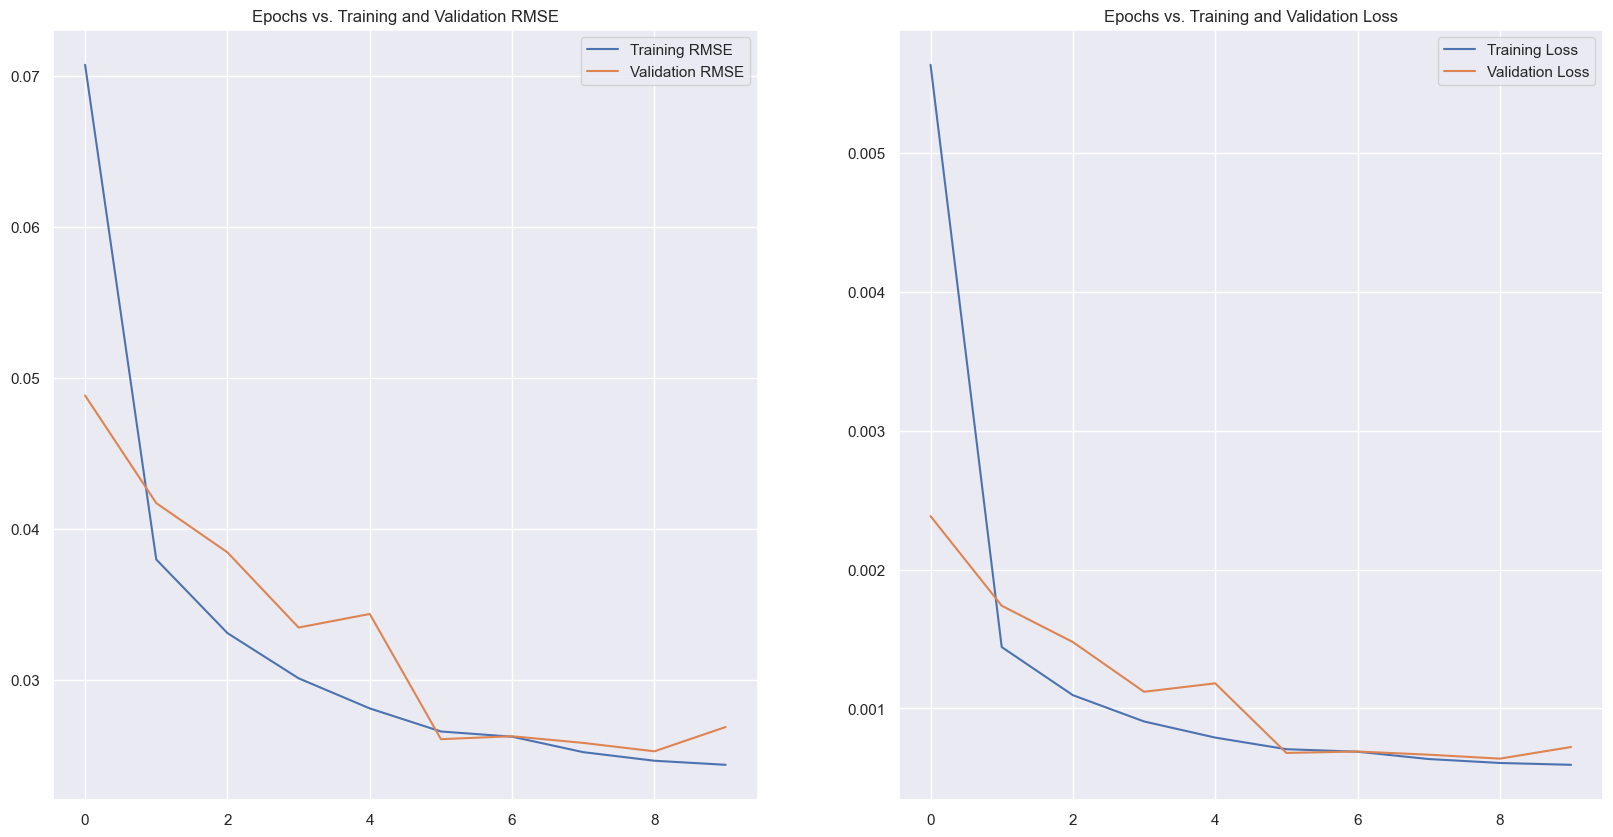

In [ ]:
plot_model_rmse_and_loss(history)

In [ ]:
encoder_decoder = tf.keras.models.load_model('encoder_decoder.h5')

forecast = encoder_decoder.predict(X_test)
encoder_decoder_forecast = scaler_y.inverse_transform(forecast)

rmse_encoder_decoder = sqrt(mean_squared_error(y_test_inv, 
                                               encoder_decoder_forecast))
print('RMSE of hour-ahead electricity price Encoder-Decoder forecast: {}'
      .format(round(rmse_encoder_decoder, 3)))

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
RMSE of hour-ahead electricity price Encoder-Decoder forecast: 2.432
